## 1. IMPORTACIÓN Y CONFIGURACIÓN

In [1]:
# Librerías básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
from datetime import datetime
from dateutil.relativedelta import relativedelta

from statsmodels.stats.diagnostic import linear_reset
# Librerías para ARIMA y validación
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox


import statsmodels.api as sm
from scipy import stats
from sklearn.metrics import mean_squared_error, mean_absolute_error
import optuna

# Configuraciones
warnings.filterwarnings('ignore')
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print(f"Fecha de análisis: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

Fecha de análisis: 2025-12-06 15:46


## 2. CARGA DE DATOS

In [2]:
# Cargar datos del análisis exploratorio
try:
    with open('datasets_preparados.pkl', 'rb') as f:
        datasets = pickle.load(f)
    
    # Extraer datasets
    data = datasets['data']
    train_to1 = datasets['train_to1']
    train_to2 = datasets['train_to2']
    test_to1 = datasets['test_to1']
    test_to2 = datasets['test_to2']
    train_len = datasets['train_len']
    
    print("Datos cargados exitosamente")
    print(f"Configuración: {train_len} train / {len(data) - train_len} test")
    
except FileNotFoundError:
    print("Error: No se encontró 'datasets_preparados.pkl'")
    print("Ejecuta primero el notebook '01_Analisis_Exploratorio.ipynb'")

Datos cargados exitosamente
Configuración: 121 train / 6 test


## 3. TENDENCIA LINEAL

In [3]:
# Modelo de tendencia lineal para Producto 1
y = train_to1["producto1"].values  # Variable dependiente
x = np.arange(1, len(y) + 1)  # Variable independiente (índice temporal)
X = sm.add_constant(x)  # Añadir constante al modelo
lin = sm.OLS(y, X)  # Definir modelo de regresión lineal
lin_t = lin.fit()  # Ajustar modelo
print(lin_t.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.728
Model:                            OLS   Adj. R-squared:                  0.726
Method:                 Least Squares   F-statistic:                     318.7
Date:                Sat, 06 Dec 2025   Prob (F-statistic):           1.90e-35
Time:                        15:46:17   Log-Likelihood:                -640.60
No. Observations:                 121   AIC:                             1285.
Df Residuals:                     119   BIC:                             1291.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        490.8188      8.892     55.201      0.0

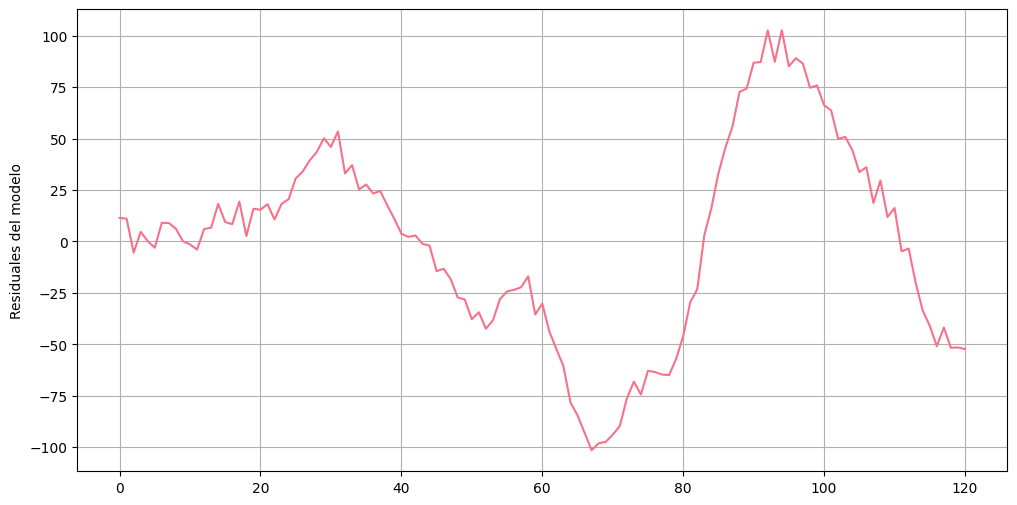

In [4]:
plt.ylabel("Residuales del modelo")
plt.plot(lin_t.resid)
plt.grid()

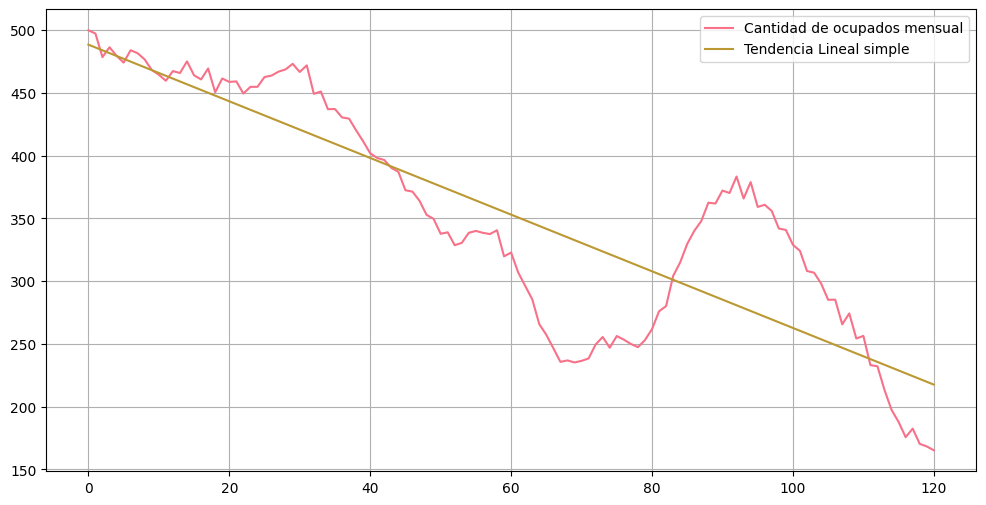

In [5]:
plt.plot(y,label="Cantidad de ocupados mensual")
plt.plot(lin_t.fittedvalues,label="Tendencia Lineal simple")
plt.legend(loc= "upper right")
plt.grid()
plt.show()

In [6]:
# Preparar datos para pronóstico (6 meses de test)
h = 6
x_for = np.arange(len(y) + 1, len(y) + h + 1)  # Índices después del entrenamiento
X_for = sm.add_constant(x_for)

In [7]:
dt = lin_t.get_prediction(X_for).summary_frame(alpha = 0.05)
y_prd = dt['mean']
yprd_ci_lower = dt['obs_ci_lower']
yprd_ci_upper = dt['obs_ci_upper']
preds = pd.DataFrame(np.column_stack([y_prd, yprd_ci_lower, yprd_ci_upper]))
preds.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds)

   Point_forecast    lower_95    upper_95
0      215.340842  117.509716  313.171969
1      213.082827  115.212271  310.953383
2      210.824811  112.914201  308.735421
3      208.566795  110.615507  306.518084
4      206.308780  108.316189  304.301370
5      204.050764  106.016249  302.085279


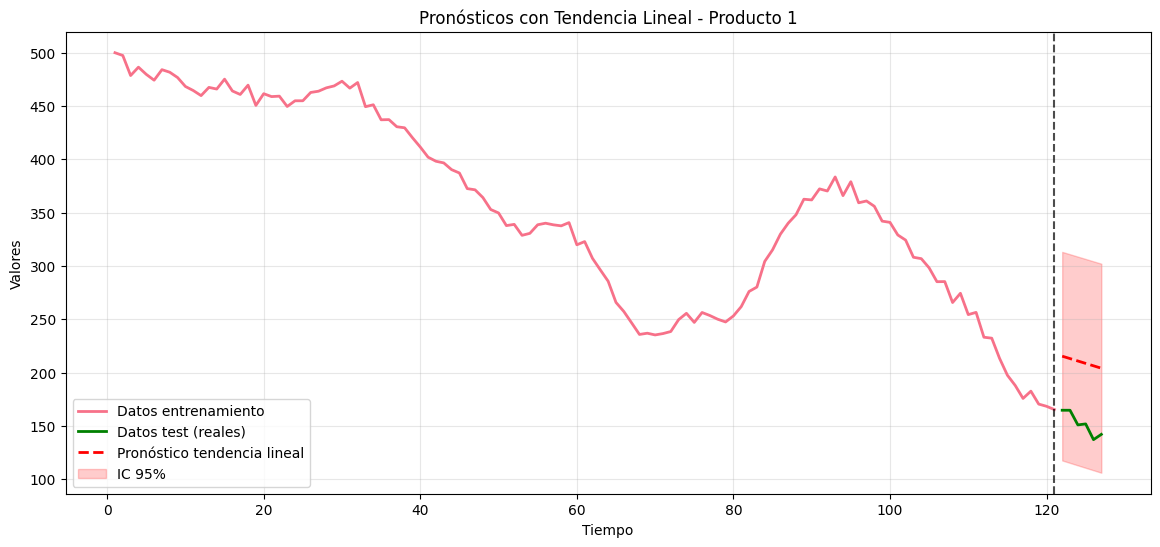

In [8]:
# Visualización de pronósticos con datos de test
plt.figure(figsize=(14, 6))
plt.plot(np.arange(1, len(y) + 1), y, label="Datos entrenamiento", linewidth=2)
plt.plot(np.arange(len(y) + 1, len(y) + len(test_to1['producto1']) + 1), 
         test_to1['producto1'].values, label="Datos test (reales)", 
         linewidth=2, color='green')
plt.plot(x_for, y_prd, label="Pronóstico tendencia lineal", 
         linewidth=2, linestyle='--', color='red')
plt.fill_between(x_for, yprd_ci_lower, yprd_ci_upper, 
                 alpha=0.2, color='red', label='IC 95%')
plt.axvline(x=len(y), color='black', linestyle='--', alpha=0.7)
plt.ylabel("Valores")
plt.xlabel("Tiempo")
plt.title("Pronósticos con Tendencia Lineal - Producto 1")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [9]:
rmse = np.sqrt(mean_squared_error(test_to1, y_prd))
print("RMSE del modelo lineal:", round(rmse, 2))

RMSE del modelo lineal: 58.29


## 4. TENDENCIA CUADRÁTICA

In [10]:
# Modelo de tendencia cuadrática para Producto 1
y_quad = train_to1["producto1"].values
train_to1["x"] = np.linspace(1, train_len, train_len)
train_to1["x2"] = train_to1["x"] ** 2
X_quad = sm.add_constant(train_to1[["x", "x2"]])  # Usar statsmodels para agregar constante
pol = sm.OLS(y_quad, X_quad)  # Modelo de regresión cuadrática
pol_2 = pol.fit()  # Ajustar modelo
print(pol_2.summary())



                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.744
Model:                            OLS   Adj. R-squared:                  0.739
Method:                 Least Squares   F-statistic:                     171.2
Date:                Sat, 06 Dec 2025   Prob (F-statistic):           1.29e-35
Time:                        15:46:17   Log-Likelihood:                -637.02
No. Observations:                 121   AIC:                             1280.
Df Residuals:                     118   BIC:                             1288.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        517.3224     13.139     39.374      0.0

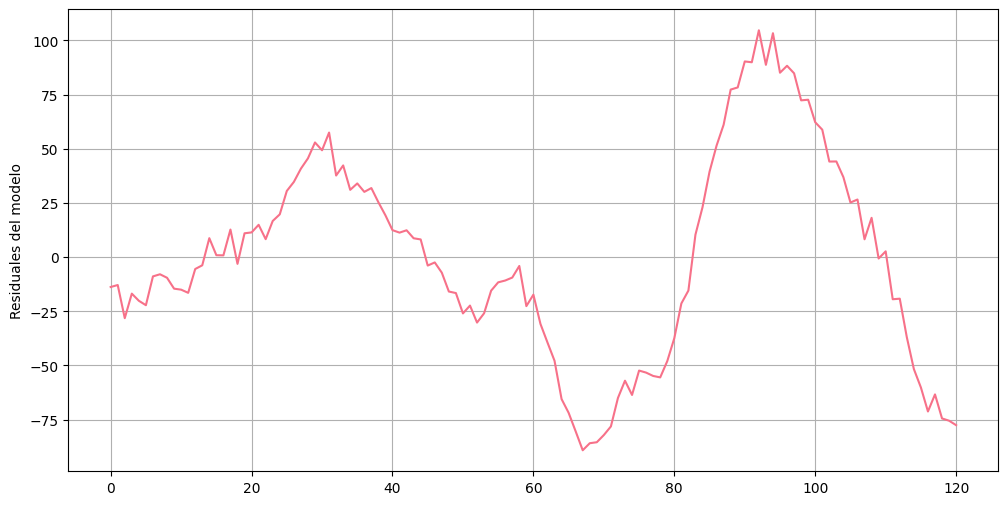

In [11]:
plt.ylabel("Residuales del modelo")
plt.plot(pol_2.resid)
plt.grid()

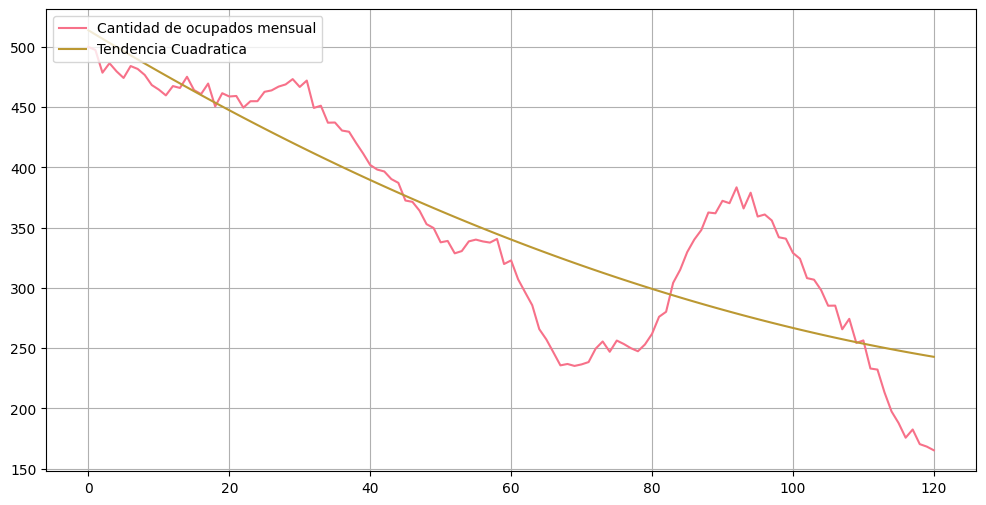

In [12]:
plt.plot(y,label="Cantidad de ocupados mensual")
plt.plot(pol_2.fittedvalues,label="Tendencia Cuadratica")
plt.legend(loc= "upper left")
plt.grid()
plt.show()

In [13]:
h = 6
x_for = np.linspace(train_to2.shape[0] + 1, train_to2.shape[0] + h, h)
X_for = sm.add_constant(np.stack((x_for, x_for**2), axis=1))

In [14]:
dt = pol_2.get_prediction(X_for).summary_frame(alpha=0.05)
y_prd = dt['mean']
yprd_ci_lower = dt['obs_ci_lower']
yprd_ci_upper = dt['obs_ci_upper']
preds = pd.DataFrame({
    'Point_forecast': y_prd,
    'lower_95': yprd_ci_lower,
    'upper_95': yprd_ci_upper
})

print(preds)

   Point_forecast    lower_95    upper_95
0      241.844477  144.477120  339.211833
1      240.889918  143.287343  338.492494
2      239.956554  142.105833  337.807276
3      239.044385  140.932223  337.156547
4      238.153410  139.766143  336.540677
5      237.283630  138.607230  335.960029


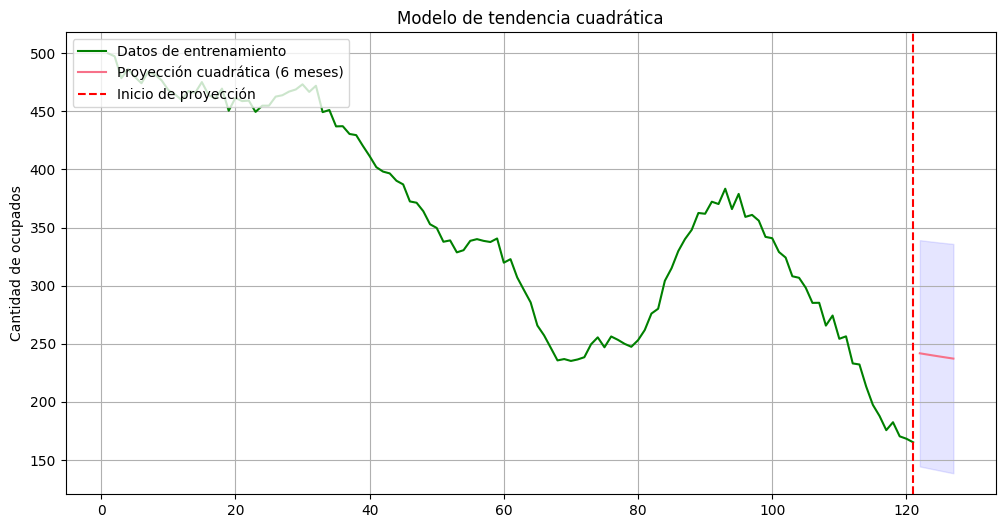

In [15]:
fig = plt.figure(figsize=(12, 6))

# Eje X numérico para entrenamiento
x = np.arange(1, train_to1.shape[0] + 1)
y = train_to1["producto1"].values

# Serie real (entrenamiento)
plt.plot(x, y, label="Datos de entrenamiento", color="green")

# Predicción futura
x_future = np.arange(train_to1.shape[0] + 1, train_to1.shape[0] + 1 + len(preds))
plt.plot(x_future,preds['Point_forecast'],label="Proyección cuadrática (6 meses)")

# Intervalo de confianza
plt.fill_between(x_future,preds['lower_95'],preds['upper_95'],color='blue',alpha=0.1)

# Línea divisoria del inicio de proyección
plt.axvline(x=train_to1.shape[0], color='red',linestyle='--',linewidth=1.5,label='Inicio de proyección')

# Detalles del gráfico
plt.title("Modelo de tendencia cuadrática")
plt.ylabel("Cantidad de ocupados")
plt.legend(loc="upper left")
plt.grid(True)
plt.show()

In [16]:
rmse_quad = np.sqrt(mean_squared_error(test_to1["producto1"], y_prd))
print("RMSE del modelo de tendencia cuadrática:", round(rmse_quad, 2))

RMSE del modelo de tendencia cuadrática: 88.16
 88.16


TENDENCIA POLINÓMICA

In [17]:
# Variables
y_train = train_to1["producto1"]
y_test = test_to1["producto1"]

# Crear variable de tiempo para ambos conjuntos
train_to1["x"] = np.linspace(1, train_to1.shape[0], train_to1.shape[0])
test_to1["x"] = np.linspace(train_to1.shape[0]+1, train_to1.shape[0]+test_to1.shape[0], test_to1.shape[0])
# Rango de grados polinómicos a probar
grados = [2, 3, 4, 5, 6, 7, 8, 9, 10]

resultados = {}

for g in grados:
    # Crear variable x^g en ambos conjuntos
    train_to1[f"x{g}"] = train_to1["x"] ** g
    test_to1[f"x{g}"] = test_to1["x"] ** g

    # Definir las variables predictoras y añadir constante
    X_train = sm.add_constant(train_to1[["x", f"x{g}"]])
    X_test = sm.add_constant(test_to1[["x", f"x{g}"]])

    # Entrenar modelo en train
    modelo = sm.OLS(y_train, X_train).fit()

    # Predecir sobre test
    y_pred_test = modelo.predict(X_test)

    # Calcular RMSE en test
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

    # Guardar resultados
    resultados[g] = {
        "R² (train)": round(modelo.rsquared_adj, 4),
        "RMSE (test)": round(rmse, 2)
    }

# Mostrar tabla resumen
tabla_resultados = pd.DataFrame(resultados).T
tabla_resultados.index.name = "Grado del polinomio"
print(tabla_resultados)


                     R² (train)  RMSE (test)
Grado del polinomio                         
2                        0.7394        88.16
3                        0.7366        91.16
4                        0.7318        88.62
5                        0.7275        82.14
6                        0.7247        73.15
7                        0.7236        62.83
8                       -4.7665       285.36
9                      -13.3388       420.40
10                     -13.4951       427.39



Mejor grado polinómico: 7
RMSE en test: 62.83


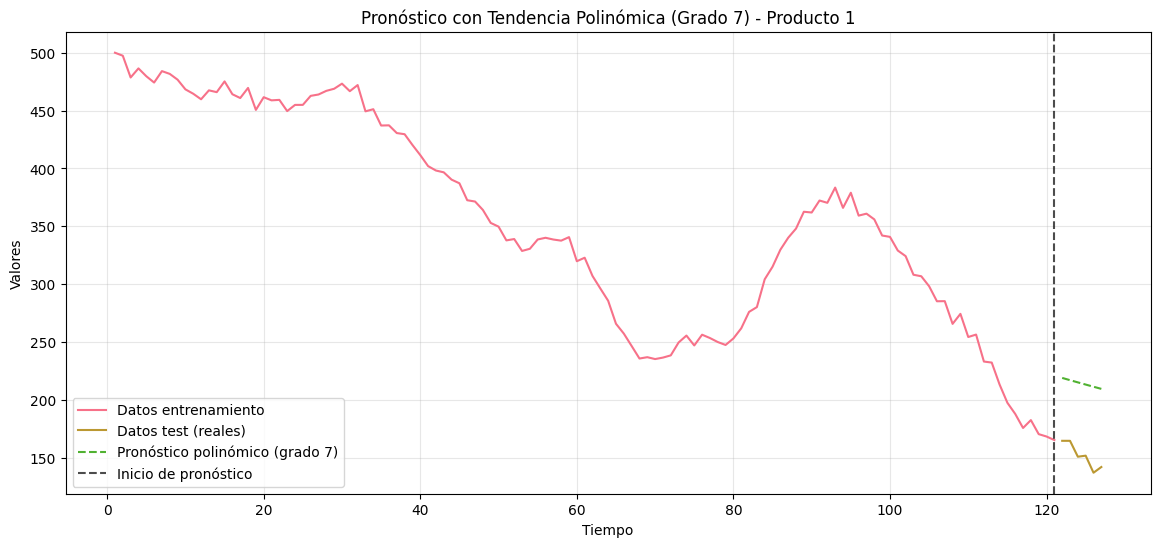

In [18]:
# Identificar el mejor grado (menor RMSE en test)
mejor_grado = tabla_resultados['RMSE (test)'].idxmin()
print(f"\nMejor grado polinómico: {mejor_grado}")
print(f"RMSE en test: {tabla_resultados.loc[mejor_grado, 'RMSE (test)']}")

# Entrenar modelo final con el mejor grado
train_to1[f"x{mejor_grado}"] = train_to1["x"] ** mejor_grado
test_to1[f"x{mejor_grado}"] = test_to1["x"] ** mejor_grado

X_train_final = sm.add_constant(train_to1[["x", f"x{mejor_grado}"]])
X_test_final = sm.add_constant(test_to1[["x", f"x{mejor_grado}"]])

modelo_final = sm.OLS(y_train, X_train_final).fit()
y_pred_final = modelo_final.predict(X_test_final)

# Visualización
plt.figure(figsize=(14, 6))

# Datos de entrenamiento
x_train = np.arange(1, len(y_train) + 1)
plt.plot(x_train, y_train.values, label="Datos entrenamiento")

# Datos de test (reales)
x_test = np.arange(len(y_train) + 1, len(y_train) + len(y_test) + 1)
plt.plot(x_test, y_test.values, label="Datos test (reales)")

# Predicciones del modelo
plt.plot(x_test, y_pred_final, label=f"Pronóstico polinómico (grado {mejor_grado})", 
         linestyle='--')

# Línea divisoria
plt.axvline(x=len(y_train), color='black', linestyle='--', alpha=0.7, 
            label='Inicio de pronóstico')

plt.ylabel("Valores")
plt.xlabel("Tiempo")
plt.title(f"Pronóstico con Tendencia Polinómica (Grado {mejor_grado}) - Producto 1")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


ESTACIONALIDAD

In [19]:
# Recargar datos originales para análisis de estacionalidad
with open('datasets_preparados.pkl', 'rb') as f:
    datasets = pickle.load(f)
train_estacional = datasets['train_to1'].copy()

# Crear índice datetime desde junio 2014
fecha_inicio = pd.Timestamp('2014-06-01')
train_estacional.index = pd.date_range(start=fecha_inicio, periods=len(train_estacional), freq='MS')

In [20]:
# Crear las dummies mensuales (todas numéricas)
month_dummies = pd.get_dummies(train_estacional.index.month, prefix='mes', drop_first=True)
month_dummies.index = train_estacional.index
# Convertir a float explícitamente
month_dummies = month_dummies.astype(float)

In [21]:
# Verificar el índice creado
print(f"Longitud del dataset: {len(train_estacional)}")
print(f"\nDistribución de meses:")
print(train_estacional.index.month.value_counts().sort_index())

Longitud del dataset: 121

Distribución de meses:
1     10
2     10
3     10
4     10
5     10
6     11
7     10
8     10
9     10
10    10
11    10
12    10
Name: count, dtype: int64


In [22]:
# Definir las variables
y = train_estacional["producto1"].astype(float)
X = sm.add_constant(month_dummies)

# Ajustar modelo OLS
sea = sm.OLS(y, X)
season = sea.fit()

# Resultado
print(season.summary())

                            OLS Regression Results                            
Dep. Variable:              producto1   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                 -0.089
Method:                 Least Squares   F-statistic:                    0.1113
Date:                Sat, 06 Dec 2025   Prob (F-statistic):               1.00
Time:                        15:46:18   Log-Likelihood:                -718.72
No. Observations:                 121   AIC:                             1461.
Df Residuals:                     109   BIC:                             1495.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        349.9488     30.624     11.427      0.0

In [23]:
month_dummies

,mes_2,mes_3,mes_4,mes_5,mes_6,mes_7,mes_8,mes_9,mes_10,mes_11,mes_12
2014-06-01,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2014-07-01,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2014-08-01,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2014-09-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2014-10-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
2024-02-01,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-03-01,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-04-01,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-05-01,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


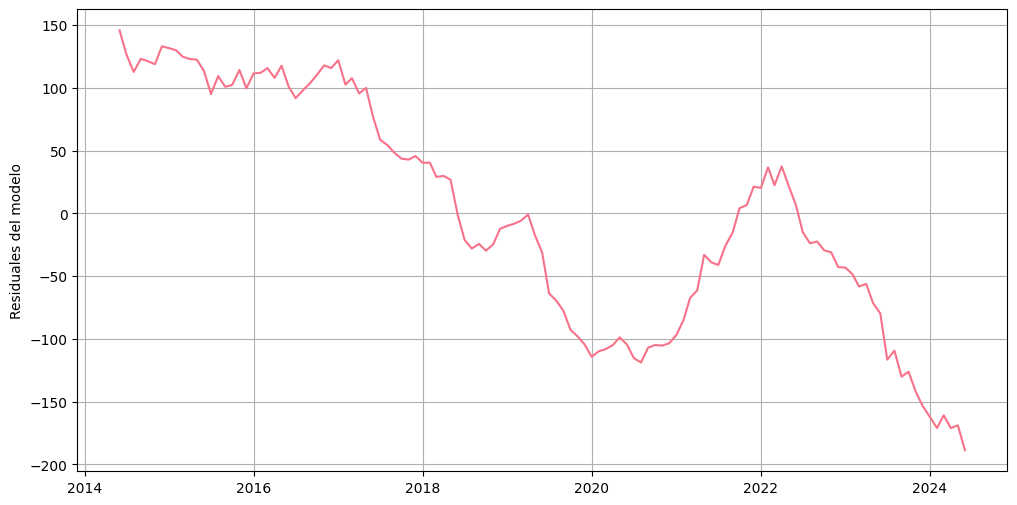

In [24]:
plt.ylabel("Residuales del modelo")
plt.plot(season.resid)
plt.grid()

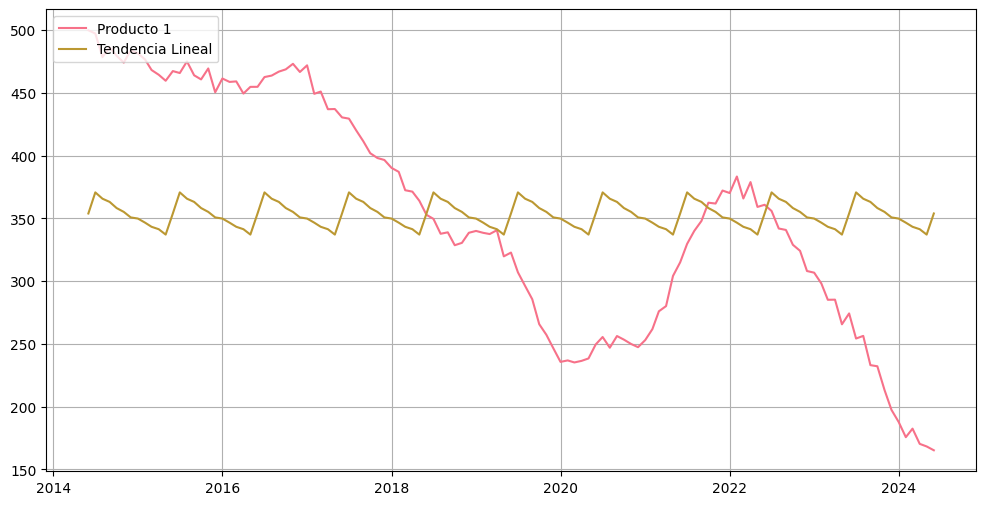

In [25]:
plt.plot(y,label="Producto 1")
plt.plot(season.fittedvalues,label="Tendencia Lineal")
plt.legend(loc= "upper left")
plt.grid()
plt.show()

In [26]:
# Generar fechas futuras para pronóstico (12 meses)
range_dates = pd.date_range(train_estacional.index[-1] + relativedelta(months=1), periods=12, freq='MS')

# Crear dummies mensuales para el pronóstico
x_for = pd.get_dummies(range_dates.month, drop_first=True).astype(float)
X_for = sm.add_constant(x_for)

In [27]:
dt = season.get_prediction(X_for).summary_frame(alpha = 0.05)
y_prd = dt['mean']
yprd_ci_lower = dt['obs_ci_lower']
yprd_ci_upper = dt['obs_ci_upper']
preds = pd.DataFrame(np.column_stack([y_prd, yprd_ci_lower, yprd_ci_upper]))
preds.columns = ['Point_forecast', 'lower_95', 'upper_95']
preds.set_index(range_dates,inplace=True)
print(preds)

            Point_forecast    lower_95    upper_95
2024-07-01      370.805129  169.497868  572.112390
2024-08-01      365.766567  164.459306  567.073828
2024-09-01      363.212228  161.904966  564.519489
2024-10-01      358.318168  157.010906  559.625429
2024-11-01      355.254852  153.947590  556.562113
2024-12-01      350.861409  149.554148  552.168670
2025-01-01      349.948789  148.641527  551.256050
2025-02-01      346.674605  145.367344  547.981866
2025-03-01      343.387344  142.080082  544.694605
2025-04-01      341.465625  140.158364  542.772887
2025-05-01      337.177527  135.870266  538.484789
2025-06-01      353.993938  153.520251  554.467625


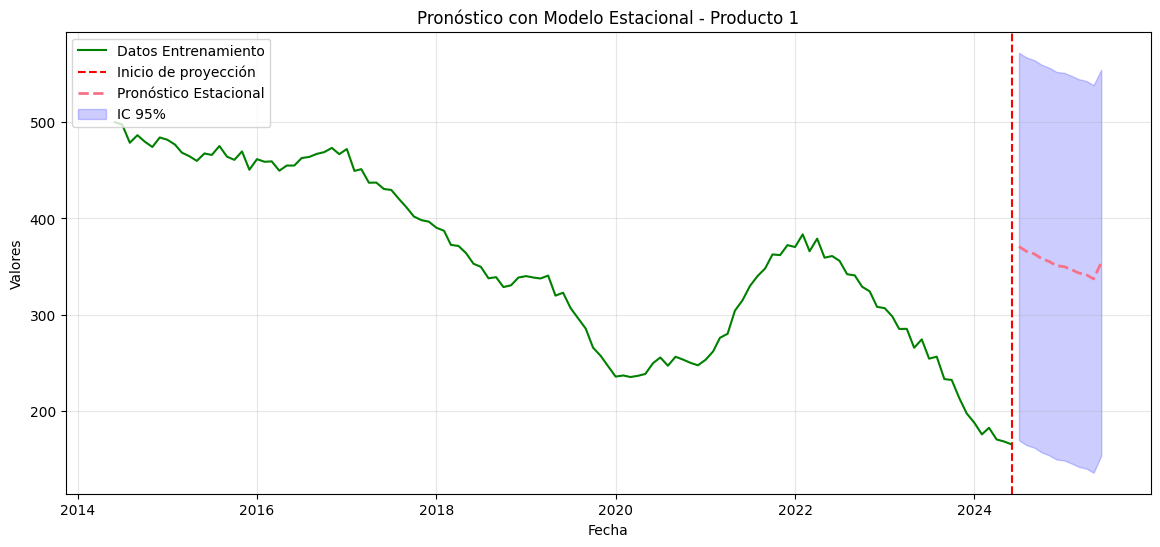

In [28]:
# Visualización del pronóstico estacional
fig = plt.figure(figsize=(14, 6))

# Datos de entrenamiento con índice datetime
plt.plot(train_estacional.index, train_estacional["producto1"], label="Datos Entrenamiento", color="green")

# Línea divisoria
plt.axvline(train_estacional.index[-1], color='red', linestyle='--', label='Inicio de proyección')

# Pronósticos con intervalos de confianza
plt.plot(preds.index, preds['Point_forecast'], label="Pronóstico Estacional", linestyle='--', linewidth=2)
plt.fill_between(preds.index, preds['lower_95'], preds['upper_95'], color='blue', alpha=0.2, label='IC 95%')

plt.ylabel("Valores")
plt.xlabel("Fecha")
plt.title("Pronóstico con Modelo Estacional - Producto 1")
plt.legend(loc="upper left")
plt.grid(alpha=0.3)
plt.show()

In [29]:
# Predicciones dentro del conjunto de entrenamiento
dt_train = season.get_prediction().summary_frame(alpha=0.05)
y_pred_train = dt_train['mean']

# Cálculo del RMSE (comparando con los valores reales)
rmse = np.sqrt(mean_squared_error(train_estacional["producto1"], y_pred_train))

print(f"RMSE del modelo lineal estacional: {rmse:.2f}")

RMSE del modelo lineal estacional: 91.92


TENDENCIA + ESTACIONALIDAD

In [30]:
y = train_estacional["producto1"]
train_estacional["x"] = np.linspace(1,train_estacional.shape[0],train_estacional.shape[0])
train_estacional["x6"] = train_estacional["x"]**6

month_dummies = pd.get_dummies(train_estacional.index.month,drop_first=True).set_index(train_estacional.index).astype(int)
X = sm.add_constant( pd.concat([train_estacional[["x","x6"]],month_dummies],axis=1) )

season_pol6 = sm.OLS(y,X)
season_pol6 = season_pol6.fit()
print(season_pol6.summary())

                            OLS Regression Results                            
Dep. Variable:              producto1   R-squared:                       0.731
Model:                            OLS   Adj. R-squared:                  0.698
Method:                 Least Squares   F-statistic:                     22.31
Date:                Sat, 06 Dec 2025   Prob (F-statistic):           9.67e-25
Time:                        15:46:19   Log-Likelihood:                -640.06
No. Observations:                 121   AIC:                             1308.
Df Residuals:                     107   BIC:                             1347.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        493.6734     19.013     25.965      0.0

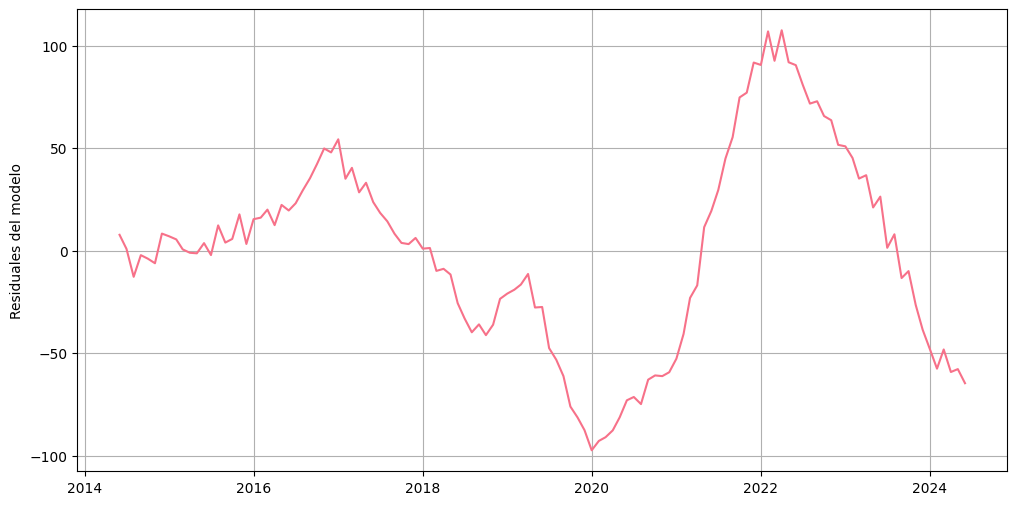

In [31]:
plt.ylabel("Residuales del modelo")
plt.plot(season_pol6.resid)
plt.grid()

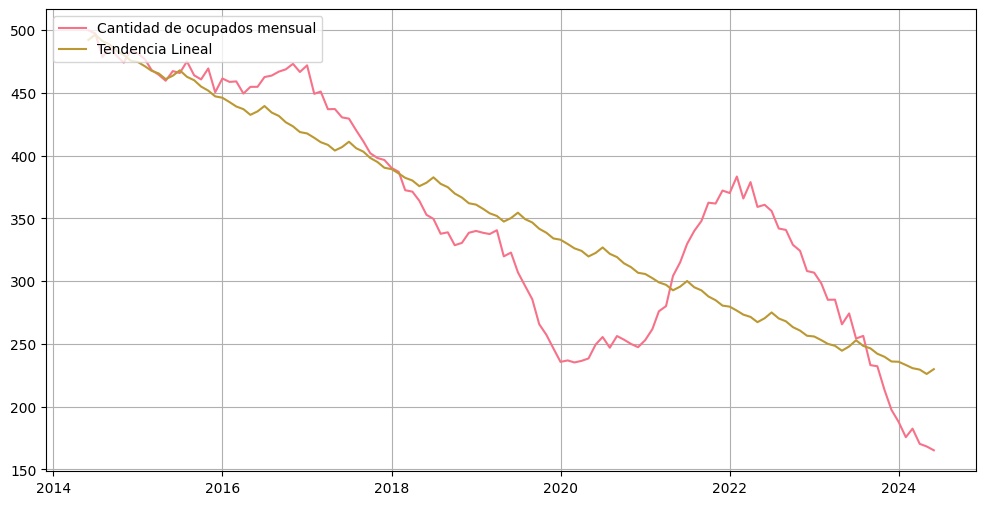

In [32]:
plt.plot(y,label="Cantidad de ocupados mensual")
plt.plot(season_pol6.fittedvalues,label="Tendencia Lineal")
plt.legend(loc="upper left")
plt.grid()
plt.show()

In [33]:
h=12
x_for= np.linspace((train_estacional.shape[0]+1),(train_estacional.shape[0]+h),h)
x_for_all = pd.DataFrame(np.stack((x_for, x_for**6),axis=1),columns=["x","x6"] )

range_dates = pd.date_range(train_estacional.index[-1]+ relativedelta(months=1), periods=h,freq='MS')
x_for_dummies = pd.get_dummies(range_dates.month,drop_first=True)

X_for= sm.add_constant(pd.concat([x_for_all,x_for_dummies],axis=1))
X_for

,const,x,x6,2,3,4,5,6,7,8,9,10,11,12
0,1.0,122.0,3.297304e+12,False,False,False,False,False,True,False,False,False,False,False
1,1.0,123.0,3.462826e+12,False,False,False,False,False,False,True,False,False,False,False
2,1.0,124.0,3.635215e+12,False,False,False,False,False,False,False,True,False,False,False
3,1.0,125.0,3.814697e+12,False,False,False,False,False,False,False,False,True,False,False
4,1.0,126.0,4.001504e+12,False,False,False,False,False,False,False,False,False,True,False
5,1.0,127.0,4.195873e+12,False,False,False,False,False,False,False,False,False,False,True
6,1.0,128.0,4.398047e+12,False,False,False,False,False,False,False,False,False,False,False
7,1.0,129.0,4.608274e+12,True,False,False,False,False,False,False,False,False,False,False
8,1.0,130.0,4.826809e+12,False,True,False,False,False,False,False,False,False,False,False
9,1.0,131.0,5.053913e+12,False,False,True,False,False,False,False,False,False,False,False


In [34]:
dt = season_pol6.get_prediction(X_for.astype(int)).summary_frame(alpha = 0.05)
y_prd = dt['mean']
yprd_ci_lower = dt['obs_ci_lower']
yprd_ci_upper = dt['obs_ci_upper']
preds = pd.DataFrame(np.column_stack([y_prd, yprd_ci_lower, yprd_ci_upper]))
preds.columns = ['Point_forecast', 'lower_95', 'upper_95']
preds.set_index(range_dates,inplace=True)
preds = preds.iloc[:6]
print(preds)

            Point_forecast    lower_95    upper_95
2024-07-01      235.316471  122.067175  348.565767
2024-08-01      231.307197  117.145475  345.468919
2024-09-01      229.823188  114.647910  344.998466
2024-10-01      226.041769  109.744721  342.338817
2024-11-01      224.134701  106.600425  341.668978
2024-12-01      220.942438  102.048098  339.836778


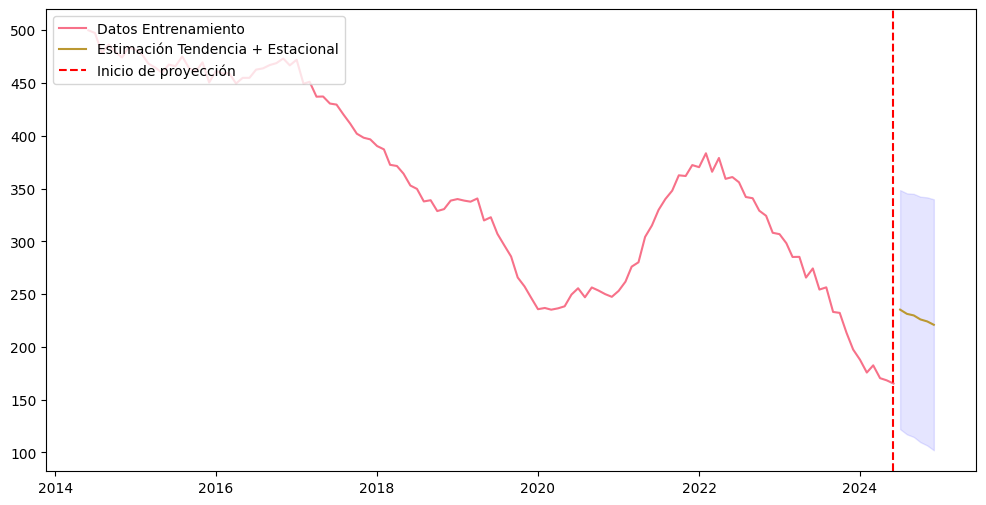

In [35]:
fig = plt.figure(figsize=(12, 6))
plt.plot(y.index,y,label="Datos Entrenamiento")
plt.plot(preds.index,preds['Point_forecast'],label="Estimación Tendencia + Estacional")
plt.axvline(train_estacional.index[-1], color='red', linestyle='--', label='Inicio de proyección')
plt.fill_between(preds.index,preds['lower_95'], preds['upper_95'], color='blue', alpha=0.1)
plt.legend(loc="upper left")
plt.show()

In [36]:
y_true = train_estacional["producto1"]
y_pred = season_pol6.fittedvalues

# cálculo del RMSE
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print(f"RMSE del modelo tendencia + estacionalidad: {rmse:.2f}")

RMSE del modelo tendencia + estacionalidad: 47.98


## **Validación de supuestos** ##

In [37]:
# ==================== VALIDACIÓN DE SUPUESTOS DEL MODELO ====================
# Modelo: Tendencia Polinómica (grado 6) + Estacionalidad

print("="*70)
print("VALIDACIÓN DE SUPUESTOS - MODELO TENDENCIA + ESTACIONALIDAD")
print("="*70)

# Extraer residuos del modelo
residuos = season_pol6.resid

print(f"\n1. ESTADÍSTICAS DESCRIPTIVAS DE RESIDUOS")
print("-"*70)
print(f"   Media de residuos: {residuos.mean():.6f}")
print(f"   Desviación estándar: {residuos.std():.4f}")
print(f"   Mínimo: {residuos.min():.4f}")
print(f"   Máximo: {residuos.max():.4f}")

# ==================== SUPUESTO 1: NORMALIDAD DE RESIDUOS ====================
print(f"\n2. SUPUESTO DE NORMALIDAD")
print("-"*70)

# Test de Jarque-Bera
jb_stat, jb_pvalue = stats.jarque_bera(residuos)
print(f"   Test Jarque-Bera:")
print(f"      Estadístico: {jb_stat:.4f}")
print(f"      p-value: {jb_pvalue:.4f}")
if jb_pvalue > 0.05:
    print(f"      ✓ No se rechaza normalidad (p > 0.05)")
else:
    print(f"      ✗ Se rechaza normalidad (p ≤ 0.05)")

# Test de Shapiro-Wilk (más robusto para muestras pequeñas)
sw_stat, sw_pvalue = stats.shapiro(residuos)
print(f"\n   Test Shapiro-Wilk:")
print(f"      Estadístico: {sw_stat:.4f}")
print(f"      p-value: {sw_pvalue:.4f}")
if sw_pvalue > 0.05:
    print(f"      ✓ No se rechaza normalidad (p > 0.05)")
else:
    print(f"      ✗ Se rechaza normalidad (p ≤ 0.05)")

# ==================== SUPUESTO 2: HOMOCEDASTICIDAD ====================
print(f"\n3. SUPUESTO DE HOMOCEDASTICIDAD (Varianza Constante)")
print("-"*70)

# Test de Breusch-Pagan
from statsmodels.stats.diagnostic import het_breuschpagan

# Reconstruir X para el test
y_test = train_estacional["producto1"]
month_dummies_test = pd.get_dummies(train_estacional.index.month, drop_first=True).set_index(train_estacional.index).astype(int)
X_test = sm.add_constant(pd.concat([train_estacional[["x", "x6"]], month_dummies_test], axis=1))

bp_stat, bp_pvalue, bp_f, bp_f_pvalue = het_breuschpagan(residuos, X_test)
print(f"   Test Breusch-Pagan:")
print(f"      Estadístico LM: {bp_stat:.4f}")
print(f"      p-value: {bp_pvalue:.4f}")
if bp_pvalue > 0.05:
    print(f"      ✓ No se rechaza homocedasticidad (p > 0.05)")
else:
    print(f"      ✗ Se rechaza homocedasticidad - posible heterocedasticidad (p ≤ 0.05)")

# ==================== SUPUESTO 3: INDEPENDENCIA (NO AUTOCORRELACIÓN) ====================
print(f"\n4. SUPUESTO DE INDEPENDENCIA (No Autocorrelación)")
print("-"*70)

# Test de Durbin-Watson
from statsmodels.stats.stattools import durbin_watson
dw_stat = durbin_watson(residuos)
print(f"   Test Durbin-Watson:")
print(f"      Estadístico DW: {dw_stat:.4f}")
print(f"      Interpretación:")
if 1.5 < dw_stat < 2.5:
    print(f"      ✓ No hay autocorrelación significativa (1.5 < DW < 2.5)")
elif dw_stat < 1.5:
    print(f"      ✗ Posible autocorrelación positiva (DW < 1.5)")
else:
    print(f"      ✗ Posible autocorrelación negativa (DW > 2.5)")

# Test de Ljung-Box (autocorrelación en múltiples lags)
ljung_box_result = acorr_ljungbox(residuos, lags=10, return_df=True)
print(f"\n   Test Ljung-Box (Autocorrelación hasta lag 10):")
print(f"      p-value (lag 10): {ljung_box_result['lb_pvalue'].iloc[-1]:.4f}")
if ljung_box_result['lb_pvalue'].iloc[-1] > 0.05:
    print(f"      ✓ No se detecta autocorrelación significativa (p > 0.05)")
    print(f"      Los residuos parecen ruido blanco")
else:
    print(f"      ✗ Se detecta autocorrelación (p ≤ 0.05)")
    print(f"      Posibles patrones temporales en residuos")

# ==================== SUPUESTO 4: LINEALIDAD ====================
print(f"\n5. SUPUESTO DE LINEALIDAD")
print("-"*70)

# Test RESET de Ramsey
reset_result = linear_reset(season_pol6, power=2, test_type='fitted', use_f=True)
reset_stat = reset_result.statistic
reset_pvalue = reset_result.pvalue

print(f"   Test RESET de Ramsey:")
print(f"      Estadístico F: {reset_stat:.4f}")
print(f"      p-value: {reset_pvalue:.4f}")
if reset_pvalue > 0.05:
    print(f"      ✓ No se rechaza especificación lineal (p > 0.05)")
    print(f"      El modelo parece bien especificado")
else:
    print(f"      ✗ Posible no linealidad o mala especificación (p ≤ 0.05)")

# ==================== RESUMEN GENERAL ====================
print(f"\n" + "="*70)
print("RESUMEN DE VALIDACIÓN DE SUPUESTOS")
print("="*70)

supuestos_cumplidos = []
supuestos_no_cumplidos = []

if jb_pvalue > 0.05 and sw_pvalue > 0.05:
    supuestos_cumplidos.append("✓ Normalidad de residuos")
else:
    supuestos_no_cumplidos.append("✗ Normalidad de residuos")

if bp_pvalue > 0.05:
    supuestos_cumplidos.append("✓ Homocedasticidad")
else:
    supuestos_no_cumplidos.append("✗ Homocedasticidad")

if 1.5 < dw_stat < 2.5 and ljung_box_result['lb_pvalue'].iloc[-1] > 0.05:
    supuestos_cumplidos.append("✓ Independencia (No autocorrelación)")
else:
    supuestos_no_cumplidos.append("✗ Independencia (Autocorrelación detectada)")

if reset_pvalue > 0.05:
    supuestos_cumplidos.append("✓ Especificación lineal correcta")
else:
    supuestos_no_cumplidos.append("✗ Especificación del modelo")

print("\nSupuestos CUMPLIDOS:")
for supuesto in supuestos_cumplidos:
    print(f"   {supuesto}")

if supuestos_no_cumplidos:
    print("\nSupuestos NO CUMPLIDOS:")
    for supuesto in supuestos_no_cumplidos:
        print(f"   {supuesto}")

print("\n" + "="*70)
if len(supuestos_cumplidos) >= 3:
    print("CONCLUSIÓN: El modelo cumple la mayoría de supuestos")
    print("Los resultados son confiables para inferencia y pronóstico")
else:
    print("CONCLUSIÓN: Varios supuestos no se cumplen")
    print("Considerar transformaciones o modelos alternativos")
print("="*70)

VALIDACIÓN DE SUPUESTOS - MODELO TENDENCIA + ESTACIONALIDAD

1. ESTADÍSTICAS DESCRIPTIVAS DE RESIDUOS
----------------------------------------------------------------------
   Media de residuos: 0.000418
   Desviación estándar: 48.1803
   Mínimo: -97.3449
   Máximo: 107.4420

2. SUPUESTO DE NORMALIDAD
----------------------------------------------------------------------
   Test Jarque-Bera:
      Estadístico: 1.3024
      p-value: 0.5214
      ✓ No se rechaza normalidad (p > 0.05)

   Test Shapiro-Wilk:
      Estadístico: 0.9839
      p-value: 0.1582
      ✓ No se rechaza normalidad (p > 0.05)

3. SUPUESTO DE HOMOCEDASTICIDAD (Varianza Constante)
----------------------------------------------------------------------
   Test Breusch-Pagan:
      Estadístico LM: 43.7442
      p-value: 0.0000
      ✗ Se rechaza homocedasticidad - posible heterocedasticidad (p ≤ 0.05)

4. SUPUESTO DE INDEPENDENCIA (No Autocorrelación)
----------------------------------------------------------------------


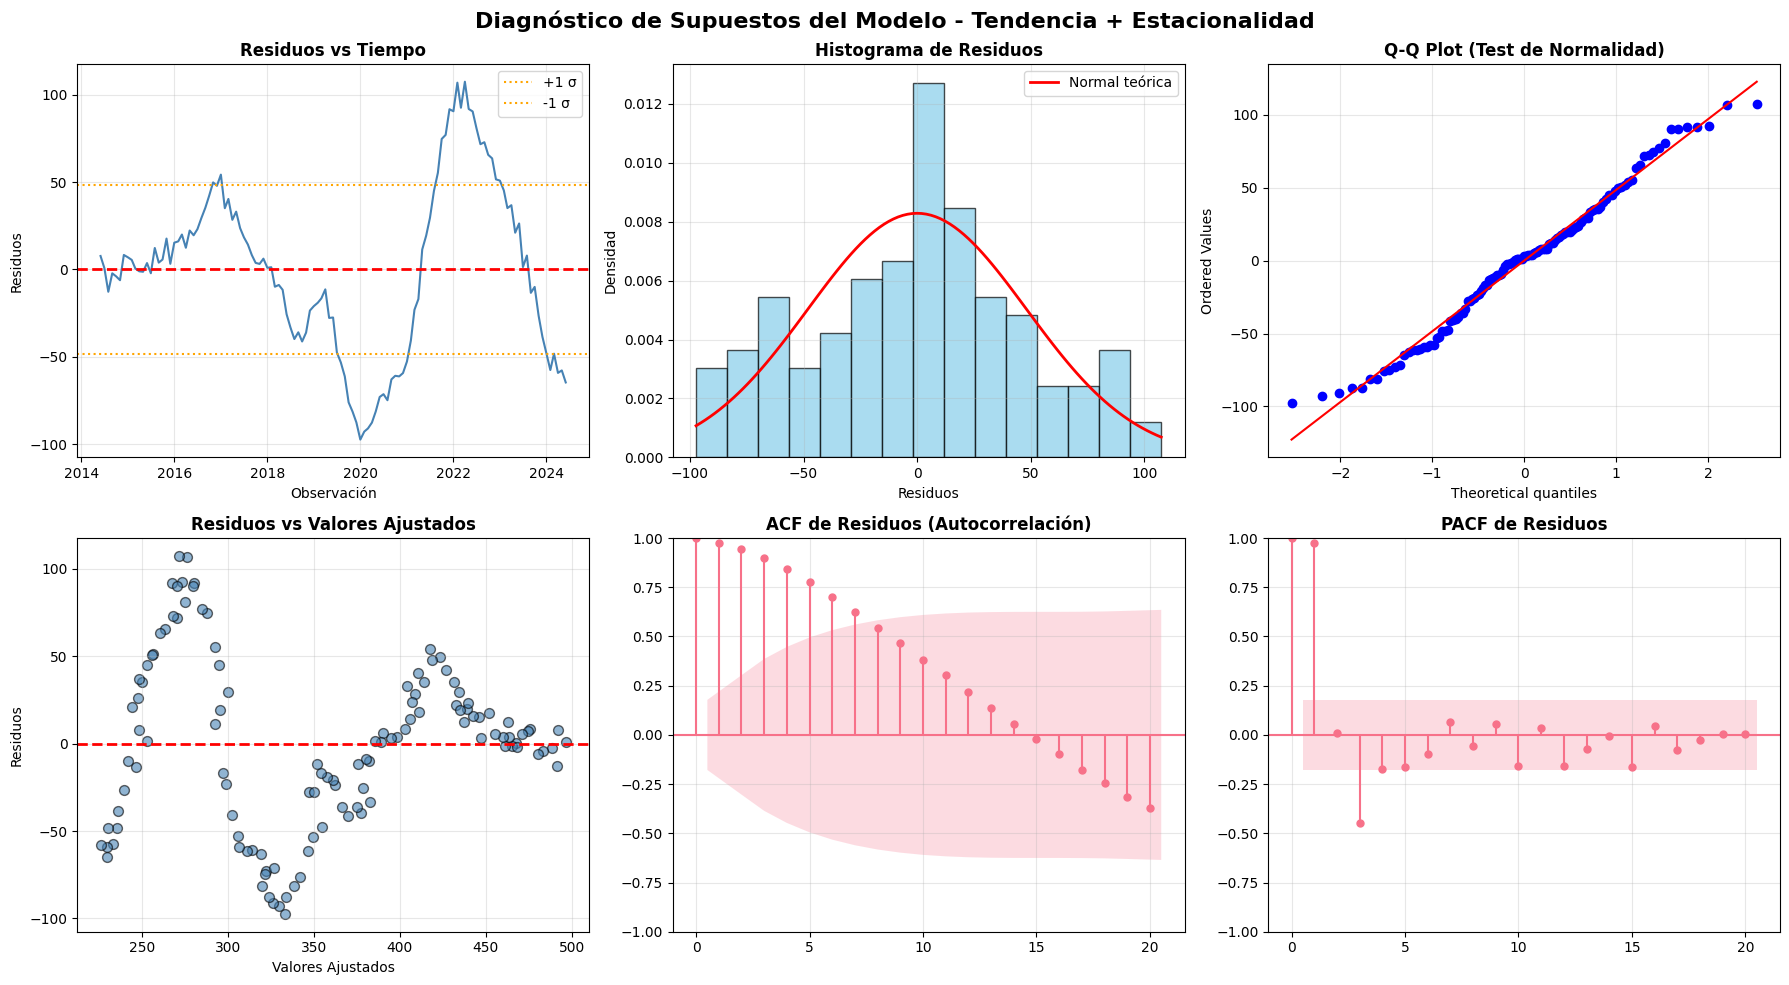

In [38]:
# ==================== VISUALIZACIÓN DE SUPUESTOS ====================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Diagnóstico de Supuestos del Modelo - Tendencia + Estacionalidad', 
             fontsize=16, fontweight='bold')

# 1. Residuos vs Tiempo
axes[0, 0].plot(residuos, color='steelblue', linewidth=1.5)
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0, 0].axhline(y=residuos.std(), color='orange', linestyle=':', linewidth=1.5, label='+1 σ')
axes[0, 0].axhline(y=-residuos.std(), color='orange', linestyle=':', linewidth=1.5, label='-1 σ')
axes[0, 0].set_title('Residuos vs Tiempo', fontweight='bold')
axes[0, 0].set_xlabel('Observación')
axes[0, 0].set_ylabel('Residuos')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. Histograma de Residuos
axes[0, 1].hist(residuos, bins=15, color='skyblue', edgecolor='black', alpha=0.7, density=True)
# Superponer distribución normal
mu, sigma = residuos.mean(), residuos.std()
x = np.linspace(residuos.min(), residuos.max(), 100)
axes[0, 1].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normal teórica')
axes[0, 1].set_title('Histograma de Residuos', fontweight='bold')
axes[0, 1].set_xlabel('Residuos')
axes[0, 1].set_ylabel('Densidad')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 3. Q-Q Plot (Normalidad)
stats.probplot(residuos, dist="norm", plot=axes[0, 2])
axes[0, 2].set_title('Q-Q Plot (Test de Normalidad)', fontweight='bold')
axes[0, 2].grid(alpha=0.3)

# 4. Residuos vs Valores Ajustados (Homocedasticidad)
fitted_values = season_pol6.fittedvalues
axes[1, 0].scatter(fitted_values, residuos, alpha=0.6, color='steelblue', edgecolors='black', s=50)
axes[1, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 0].set_title('Residuos vs Valores Ajustados', fontweight='bold')
axes[1, 0].set_xlabel('Valores Ajustados')
axes[1, 0].set_ylabel('Residuos')
axes[1, 0].grid(alpha=0.3)

# 5. ACF de Residuos (Autocorrelación)
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuos, lags=20, ax=axes[1, 1], alpha=0.05)
axes[1, 1].set_title('ACF de Residuos (Autocorrelación)', fontweight='bold')
axes[1, 1].grid(alpha=0.3)

# 6. PACF de Residuos
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(residuos, lags=20, ax=axes[1, 2], alpha=0.05)
axes[1, 2].set_title('PACF de Residuos', fontweight='bold')
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# ANÁLISIS PRODUCTO 2
# ============================================================

## 3. TENDENCIA LINEAL - PRODUCTO 2

In [39]:
# Modelo de tendencia lineal para Producto 2
y_p2 = train_to2["producto2"].values  # Variable dependiente
x_p2 = np.arange(1, len(y_p2) + 1)  # Variable independiente (índice temporal)
X_p2 = sm.add_constant(x_p2)  # Añadir constante al modelo
lin_p2 = sm.OLS(y_p2, X_p2)  # Definir modelo de regresión lineal
lin_t_p2 = lin_p2.fit()  # Ajustar modelo
print(lin_t_p2.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.762
Model:                            OLS   Adj. R-squared:                  0.760
Method:                 Least Squares   F-statistic:                     381.3
Date:                Sat, 06 Dec 2025   Prob (F-statistic):           6.49e-39
Time:                        15:46:20   Log-Likelihood:                -706.36
No. Observations:                 121   AIC:                             1417.
Df Residuals:                     119   BIC:                             1422.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        318.2294     15.311     20.784      0.0

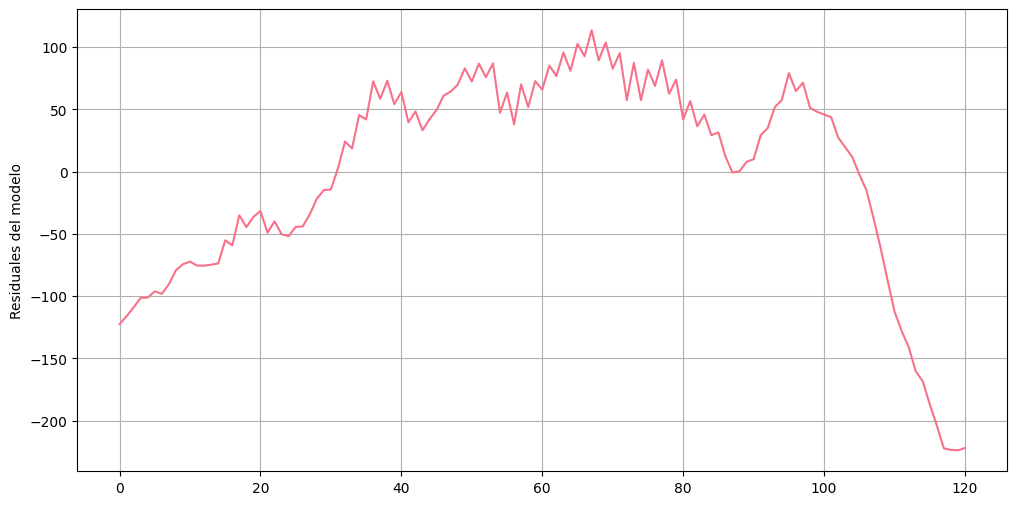

In [40]:
plt.ylabel("Residuales del modelo")
plt.plot(lin_t_p2.resid)
plt.grid()

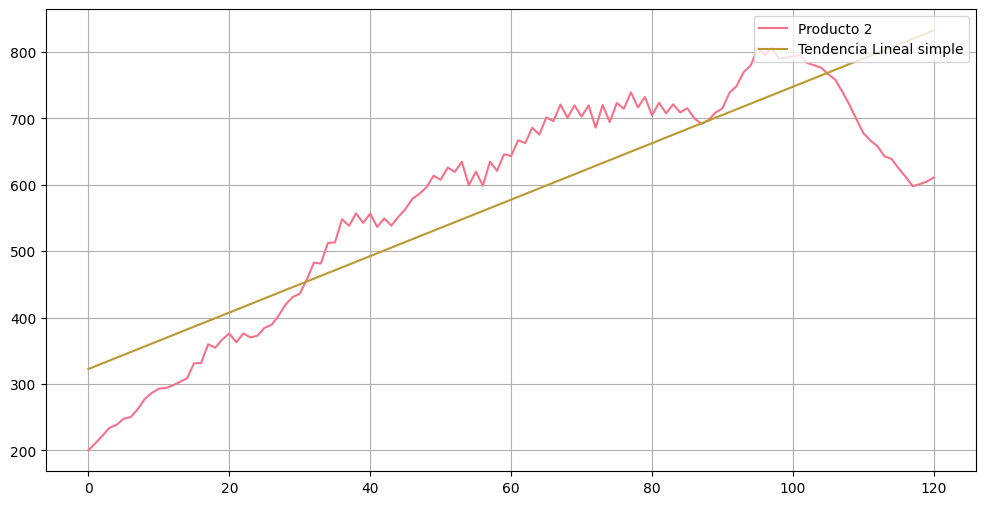

In [41]:
plt.plot(y_p2,label="Producto 2")
plt.plot(lin_t_p2.fittedvalues,label="Tendencia Lineal simple")
plt.legend(loc= "upper right")
plt.grid()
plt.show()

In [42]:
# Preparar datos para pronóstico (6 meses de test) - Producto 2
h = 6
x_for_p2 = np.arange(len(y_p2) + 1, len(y_p2) + h + 1)  # Índices después del entrenamiento
X_for_p2 = sm.add_constant(x_for_p2)

In [43]:
dt_p2 = lin_t_p2.get_prediction(X_for_p2).summary_frame(alpha = 0.05)
y_prd_p2 = dt_p2['mean']
yprd_ci_lower_p2 = dt_p2['obs_ci_lower']
yprd_ci_upper_p2 = dt_p2['obs_ci_upper']
preds_p2 = pd.DataFrame(np.column_stack([y_prd_p2, yprd_ci_lower_p2, yprd_ci_upper_p2]))
preds_p2.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds_p2)

   Point_forecast    lower_95     upper_95
0      837.128427  668.665840  1005.591014
1      841.381698  672.851215  1009.912182
2      845.634969  677.035513  1014.234425
3      849.888240  681.218737  1018.557743
4      854.141511  685.400887  1022.882135
5      858.394782  689.581966  1027.207598


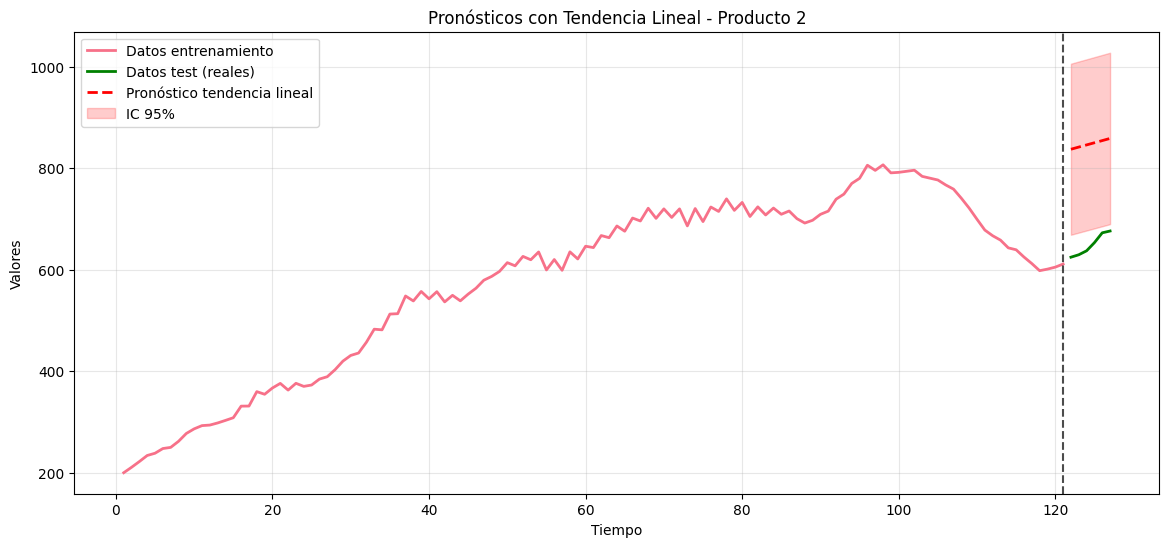

In [44]:
# Visualización de pronósticos con datos de test - Producto 2
plt.figure(figsize=(14, 6))
plt.plot(np.arange(1, len(y_p2) + 1), y_p2, label="Datos entrenamiento", linewidth=2)
plt.plot(np.arange(len(y_p2) + 1, len(y_p2) + len(test_to2['producto2']) + 1), 
         test_to2['producto2'].values, label="Datos test (reales)", 
         linewidth=2, color='green')
plt.plot(x_for_p2, y_prd_p2, label="Pronóstico tendencia lineal", 
         linewidth=2, linestyle='--', color='red')
plt.fill_between(x_for_p2, yprd_ci_lower_p2, yprd_ci_upper_p2, 
                 alpha=0.2, color='red', label='IC 95%')
plt.axvline(x=len(y_p2), color='black', linestyle='--', alpha=0.7)
plt.ylabel("Valores")
plt.xlabel("Tiempo")
plt.title("Pronósticos con Tendencia Lineal - Producto 2")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [45]:
rmse_p2 = np.sqrt(mean_squared_error(test_to2["producto2"], y_prd_p2))
print("RMSE del modelo lineal Producto 2:", round(rmse_p2, 2))

RMSE del modelo lineal Producto 2: 199.42


## 4. TENDENCIA CUADRÁTICA - PRODUCTO 2

In [46]:
# Modelo de tendencia cuadrática para Producto 2
y_quad_p2 = train_to2["producto2"].values
train_to2["x"] = np.linspace(1, train_len, train_len)
train_to2["x2"] = train_to2["x"] ** 2
X_quad_p2 = sm.add_constant(train_to2[["x", "x2"]])  # Usar statsmodels para agregar constante
pol_p2 = sm.OLS(y_quad_p2, X_quad_p2)  # Modelo de regresión cuadrática
pol_2_p2 = pol_p2.fit()  # Ajustar modelo
print(pol_2_p2.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.959
Model:                            OLS   Adj. R-squared:                  0.958
Method:                 Least Squares   F-statistic:                     1380.
Date:                Sat, 06 Dec 2025   Prob (F-statistic):           1.40e-82
Time:                        15:46:21   Log-Likelihood:                -599.98
No. Observations:                 121   AIC:                             1206.
Df Residuals:                     118   BIC:                             1214.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        145.1549      9.674     15.004      0.0

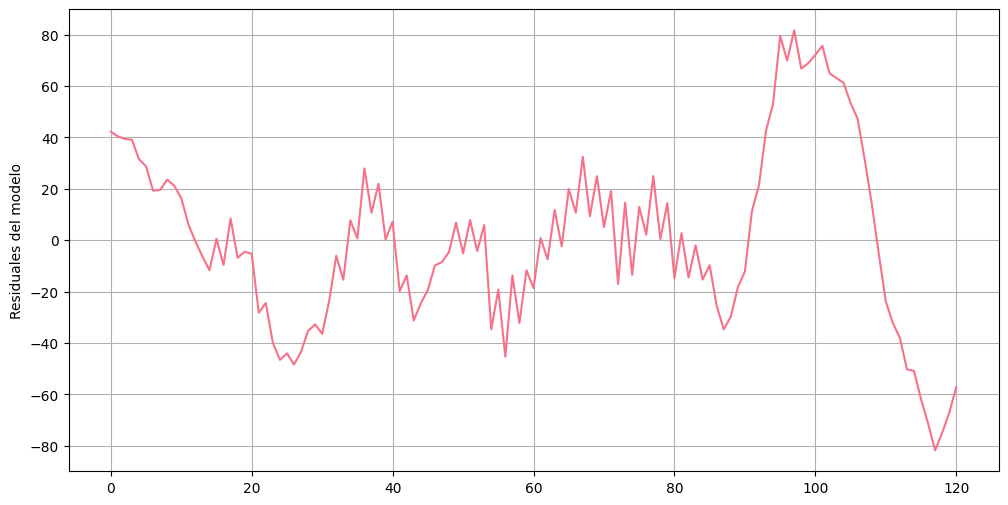

In [47]:
plt.ylabel("Residuales del modelo")
plt.plot(pol_2_p2.resid)
plt.grid()

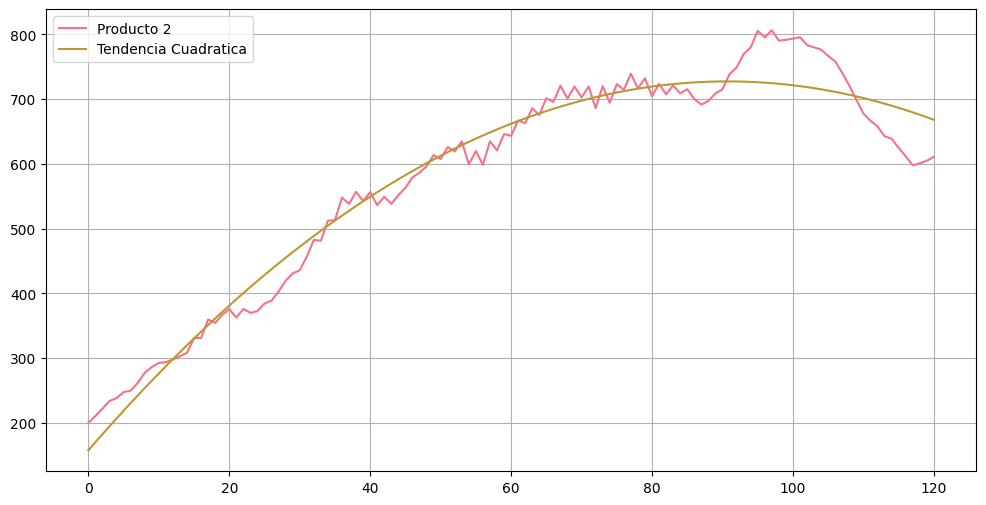

In [48]:
plt.plot(y_p2,label="Producto 2")
plt.plot(pol_2_p2.fittedvalues,label="Tendencia Cuadratica")
plt.legend(loc= "upper left")
plt.grid()
plt.show()

In [49]:
h = 6
x_for_p2 = np.linspace(train_to2.shape[0] + 1, train_to2.shape[0] + h, h)
X_for_p2 = sm.add_constant(np.stack((x_for_p2, x_for_p2**2), axis=1))

In [50]:
dt_p2 = pol_2_p2.get_prediction(X_for_p2).summary_frame(alpha=0.05)
y_prd_p2 = dt_p2['mean']
yprd_ci_lower_p2 = dt_p2['obs_ci_lower']
yprd_ci_upper_p2 = dt_p2['obs_ci_upper']
preds_p2 = pd.DataFrame({
    'Point_forecast': y_prd_p2,
    'lower_95': yprd_ci_lower_p2,
    'upper_95': yprd_ci_upper_p2
})

print(preds_p2)

   Point_forecast    lower_95    upper_95
0      664.053938  592.360937  735.746940
1      659.795349  587.929153  731.661546
2      655.398356  583.349446  727.447265
3      650.862958  578.621546  723.104371
4      646.189156  573.745180  718.633132
5      641.376950  568.720082  714.033819


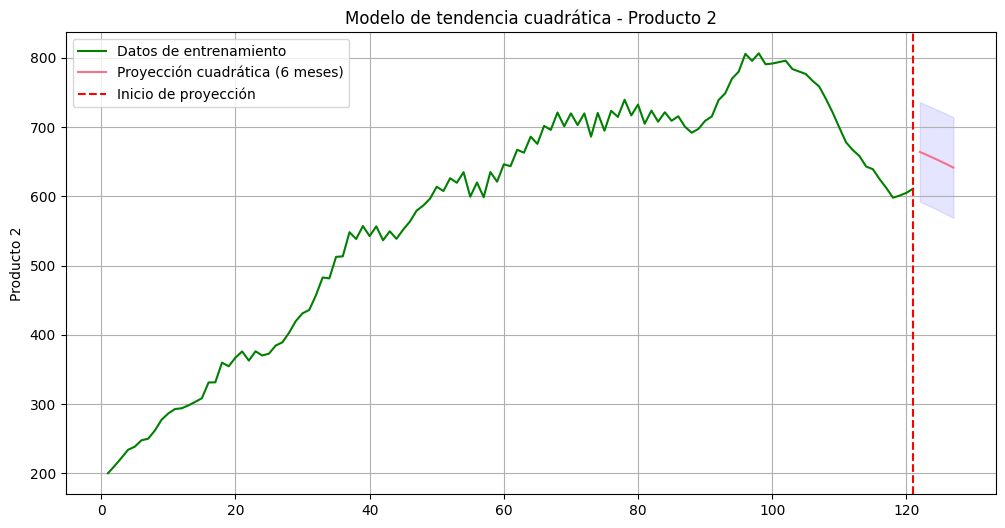

In [51]:
fig = plt.figure(figsize=(12, 6))

# Eje X numérico para entrenamiento
x = np.arange(1, train_to2.shape[0] + 1)
y = train_to2["producto2"].values

# Serie real (entrenamiento)
plt.plot(x, y, label="Datos de entrenamiento", color="green")

# Predicción futura
x_future = np.arange(train_to2.shape[0] + 1, train_to2.shape[0] + 1 + len(preds_p2))
plt.plot(x_future,preds_p2['Point_forecast'],label="Proyección cuadrática (6 meses)")

# Intervalo de confianza
plt.fill_between(x_future,preds_p2['lower_95'],preds_p2['upper_95'],color='blue',alpha=0.1)

# Línea divisoria del inicio de proyección
plt.axvline(x=train_to2.shape[0], color='red',linestyle='--',linewidth=1.5,label='Inicio de proyección')

# Detalles del gráfico
plt.title("Modelo de tendencia cuadrática - Producto 2")
plt.ylabel("Producto 2")
plt.legend(loc="upper left")
plt.grid(True)
plt.show()

In [52]:
rmse_quad_p2 = np.sqrt(mean_squared_error(test_to2["producto2"], y_prd_p2))
print("RMSE del modelo de tendencia cuadrática - Producto 2:", round(rmse_quad_p2, 2))

RMSE del modelo de tendencia cuadrática - Producto 2: 28.08


TENDENCIA POLINÓMICA - PRODUCTO 2

In [53]:
# Variables - Producto 2
y_train_p2 = train_to2["producto2"]
y_test_p2 = test_to2["producto2"]

# Crear variable de tiempo para ambos conjuntos
train_to2["x"] = np.linspace(1, train_to2.shape[0], train_to2.shape[0])
test_to2["x"] = np.linspace(train_to2.shape[0]+1, train_to2.shape[0]+test_to2.shape[0], test_to2.shape[0])
# Rango de grados polinómicos a probar
grados = [2, 3, 4, 5, 6, 7, 8, 9, 10]

resultados_p2 = {}

for g in grados:
    # Crear variable x^g en ambos conjuntos
    train_to2[f"x{g}"] = train_to2["x"] ** g
    test_to2[f"x{g}"] = test_to2["x"] ** g

    # Definir las variables predictoras y añadir constante
    X_train_p2 = sm.add_constant(train_to2[["x", f"x{g}"]])
    X_test_p2 = sm.add_constant(test_to2[["x", f"x{g}"]])

    # Entrenar modelo en train
    modelo_p2 = sm.OLS(y_train_p2, X_train_p2).fit()

    # Predecir sobre test
    y_pred_test_p2 = modelo_p2.predict(X_test_p2)

    # Calcular RMSE en test
    rmse_p2 = np.sqrt(mean_squared_error(y_test_p2, y_pred_test_p2))

    # Guardar resultados
    resultados_p2[g] = {
        "R² (train)": round(modelo_p2.rsquared_adj, 4),
        "RMSE (test)": round(rmse_p2, 2)
    }

# Mostrar tabla resumen
tabla_resultados_p2 = pd.DataFrame(resultados_p2).T
tabla_resultados_p2.index.name = "Grado del polinomio"
print(tabla_resultados_p2)

                     R² (train)  RMSE (test)
Grado del polinomio                         
2                        0.9583        28.08
3                        0.9717        56.37
4                        0.9755        95.96
5                        0.9749       133.37
6                        0.9721       168.62
7                        0.9682       202.48
8                        0.5807       382.47
9                       -8.5212       976.87
10                      -8.8192      1020.42



Mejor grado polinómico - Producto 2: 2
RMSE en test: 28.08


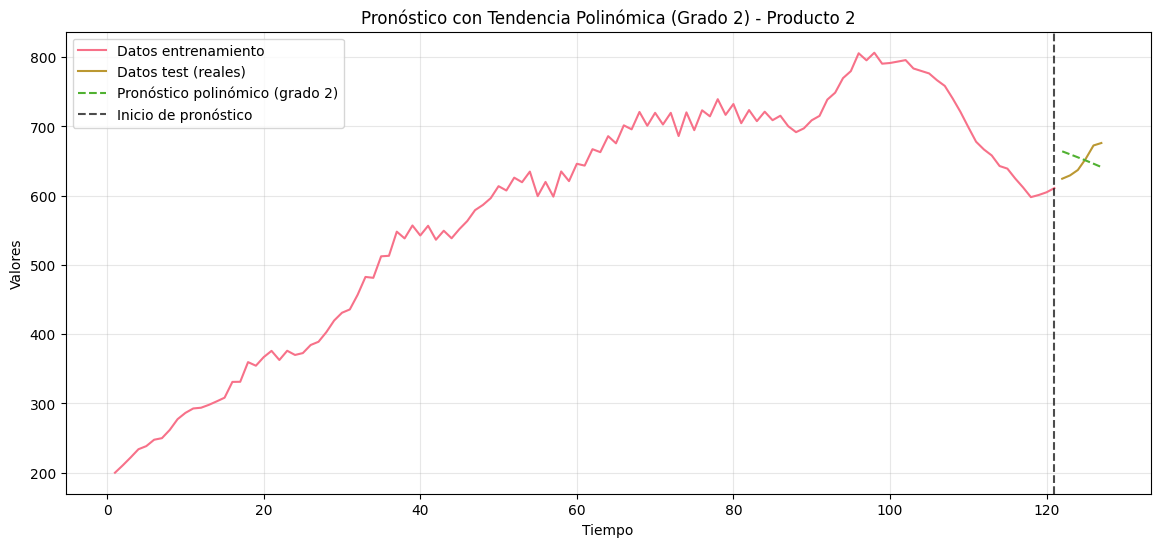

In [54]:
# Identificar el mejor grado (menor RMSE en test) - Producto 2
mejor_grado_p2 = tabla_resultados_p2['RMSE (test)'].idxmin()
print(f"\nMejor grado polinómico - Producto 2: {mejor_grado_p2}")
print(f"RMSE en test: {tabla_resultados_p2.loc[mejor_grado_p2, 'RMSE (test)']}")

# Entrenar modelo final con el mejor grado
train_to2[f"x{mejor_grado_p2}"] = train_to2["x"] ** mejor_grado_p2
test_to2[f"x{mejor_grado_p2}"] = test_to2["x"] ** mejor_grado_p2

X_train_final_p2 = sm.add_constant(train_to2[["x", f"x{mejor_grado_p2}"]])
X_test_final_p2 = sm.add_constant(test_to2[["x", f"x{mejor_grado_p2}"]])

modelo_final_p2 = sm.OLS(y_train_p2, X_train_final_p2).fit()
y_pred_final_p2 = modelo_final_p2.predict(X_test_final_p2)

# Visualización
plt.figure(figsize=(14, 6))

# Datos de entrenamiento
x_train = np.arange(1, len(y_train_p2) + 1)
plt.plot(x_train, y_train_p2.values, label="Datos entrenamiento")

# Datos de test (reales)
x_test = np.arange(len(y_train_p2) + 1, len(y_train_p2) + len(y_test_p2) + 1)
plt.plot(x_test, y_test_p2.values, label="Datos test (reales)")

# Predicciones del modelo
plt.plot(x_test, y_pred_final_p2, label=f"Pronóstico polinómico (grado {mejor_grado_p2})", 
         linestyle='--')

# Línea divisoria
plt.axvline(x=len(y_train_p2), color='black', linestyle='--', alpha=0.7, 
            label='Inicio de pronóstico')

plt.ylabel("Valores")
plt.xlabel("Tiempo")
plt.title(f"Pronóstico con Tendencia Polinómica (Grado {mejor_grado_p2}) - Producto 2")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

ESTACIONALIDAD - PRODUCTO 2

In [55]:
# Recargar datos originales para análisis de estacionalidad - Producto 2
with open('datasets_preparados.pkl', 'rb') as f:
    datasets = pickle.load(f)
train_estacional_p2 = datasets['train_to2'].copy()

# Crear índice datetime desde junio 2014
fecha_inicio = pd.Timestamp('2014-06-01')
train_estacional_p2.index = pd.date_range(start=fecha_inicio, periods=len(train_estacional_p2), freq='MS')

In [56]:
# Crear las dummies mensuales (todas numéricas) - Producto 2
month_dummies_p2 = pd.get_dummies(train_estacional_p2.index.month, prefix='mes', drop_first=True)
month_dummies_p2.index = train_estacional_p2.index
# Convertir a float explícitamente
month_dummies_p2 = month_dummies_p2.astype(float)

In [57]:
# Verificar el índice creado - Producto 2
print(f"Longitud del dataset: {len(train_estacional_p2)}")
print(f"\nDistribución de meses:")
print(train_estacional_p2.index.month.value_counts().sort_index())

Longitud del dataset: 121

Distribución de meses:
1     10
2     10
3     10
4     10
5     10
6     11
7     10
8     10
9     10
10    10
11    10
12    10
Name: count, dtype: int64


In [58]:
# Definir las variables - Producto 2
y_p2 = train_estacional_p2["producto2"].astype(float)
X_p2 = sm.add_constant(month_dummies_p2)

# Ajustar modelo OLS
sea_p2 = sm.OLS(y_p2, X_p2)
season_p2 = sea_p2.fit()

# Resultado
print(season_p2.summary())

                            OLS Regression Results                            
Dep. Variable:              producto2   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                 -0.095
Method:                 Least Squares   F-statistic:                   0.05139
Date:                Sat, 06 Dec 2025   Prob (F-statistic):               1.00
Time:                        15:46:22   Log-Likelihood:                -792.93
No. Observations:                 121   AIC:                             1610.
Df Residuals:                     109   BIC:                             1643.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        584.1084     56.551     10.329      0.0

In [59]:
month_dummies_p2

,mes_2,mes_3,mes_4,mes_5,mes_6,mes_7,mes_8,mes_9,mes_10,mes_11,mes_12
2014-06-01,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2014-07-01,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2014-08-01,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2014-09-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2014-10-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
2024-02-01,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-03-01,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-04-01,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-05-01,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


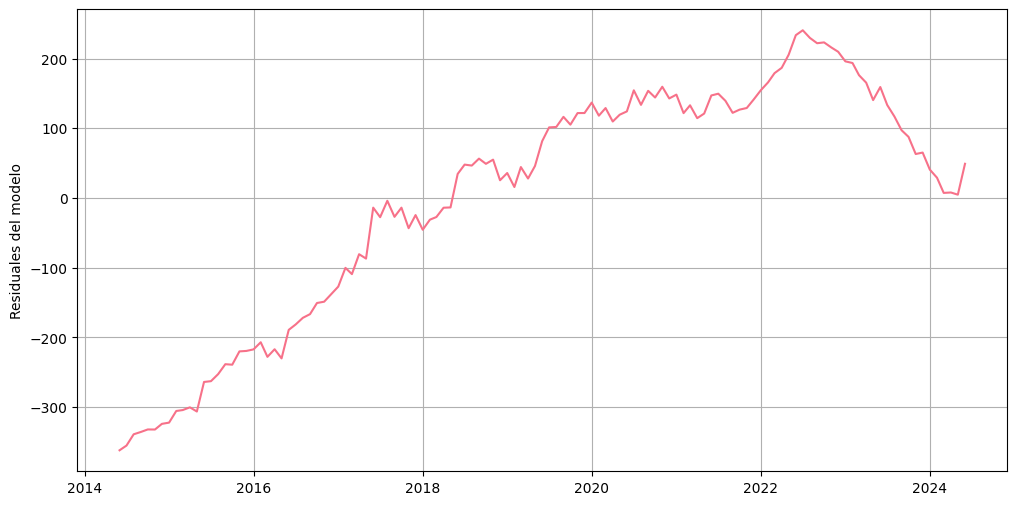

In [60]:
plt.ylabel("Residuales del modelo")
plt.plot(season_p2.resid)
plt.grid()

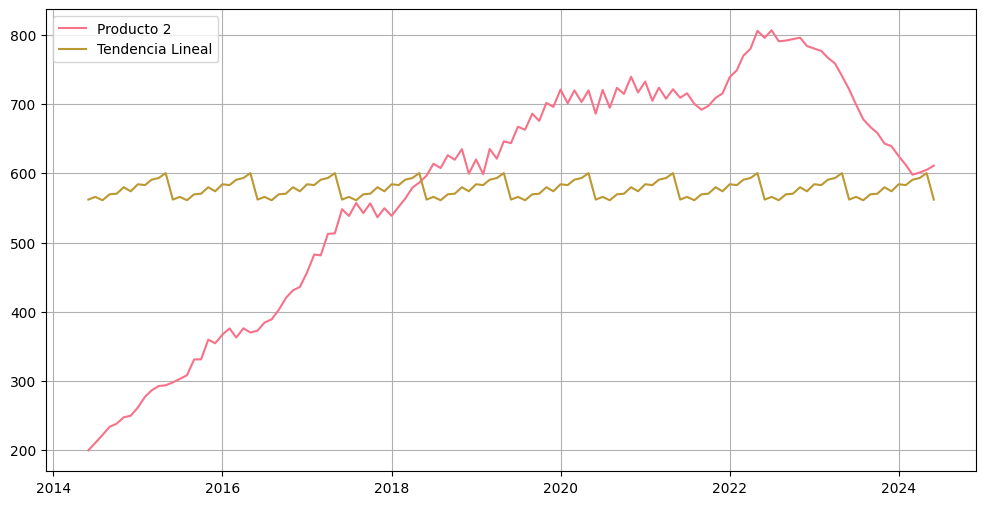

In [61]:
plt.plot(y_p2,label="Producto 2")
plt.plot(season_p2.fittedvalues,label="Tendencia Lineal")
plt.legend(loc= "upper left")
plt.grid()
plt.show()

In [62]:
# Generar fechas futuras para pronóstico (12 meses) - Producto 2
range_dates_p2 = pd.date_range(train_estacional_p2.index[-1] + relativedelta(months=1), periods=12, freq='MS')

# Crear dummies mensuales para el pronóstico
x_for_p2 = pd.get_dummies(range_dates_p2.month, drop_first=True).astype(float)
X_for_p2 = sm.add_constant(x_for_p2)

In [63]:
dt_p2 = season_p2.get_prediction(X_for_p2).summary_frame(alpha = 0.05)
y_prd_p2 = dt_p2['mean']
yprd_ci_lower_p2 = dt_p2['obs_ci_lower']
yprd_ci_upper_p2 = dt_p2['obs_ci_upper']
preds_p2 = pd.DataFrame(np.column_stack([y_prd_p2, yprd_ci_lower_p2, yprd_ci_upper_p2]))
preds_p2.columns = ['Point_forecast', 'lower_95', 'upper_95']
preds_p2.set_index(range_dates_p2,inplace=True)
print(preds_p2)

            Point_forecast    lower_95    upper_95
2024-07-01      565.873454  194.137046  937.609862
2024-08-01      561.031036  189.294628  932.767444
2024-09-01      569.602742  197.866334  941.339150
2024-10-01      570.469319  198.732911  942.205727
2024-11-01      579.800060  208.063652  951.536468
2024-12-01      573.951347  202.214939  945.687755
2025-01-01      584.108438  212.372030  955.844846
2025-02-01      582.938235  211.201827  954.674643
2025-03-01      590.667861  218.931453  962.404269
2025-04-01      593.135093  221.398685  964.871501
2025-05-01      600.192600  228.456192  971.929008
2025-06-01      561.949563  191.752443  932.146684


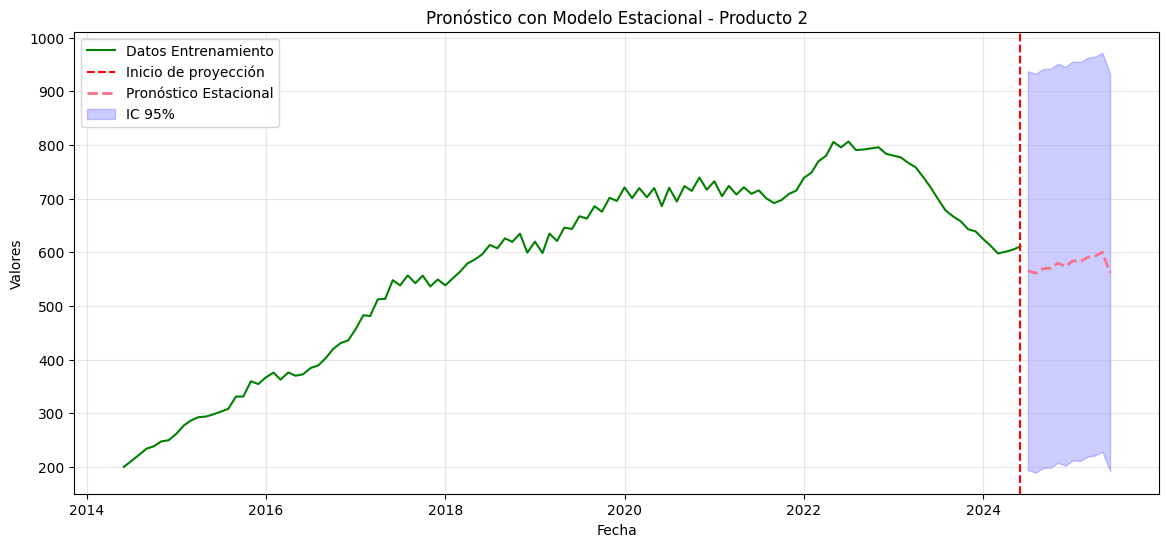

In [64]:
# Visualización del pronóstico estacional - Producto 2
fig = plt.figure(figsize=(14, 6))

# Datos de entrenamiento con índice datetime
plt.plot(train_estacional_p2.index, train_estacional_p2["producto2"], label="Datos Entrenamiento", color="green")

# Línea divisoria
plt.axvline(train_estacional_p2.index[-1], color='red', linestyle='--', label='Inicio de proyección')

# Pronósticos con intervalos de confianza
plt.plot(preds_p2.index, preds_p2['Point_forecast'], label="Pronóstico Estacional", linestyle='--', linewidth=2)
plt.fill_between(preds_p2.index, preds_p2['lower_95'], preds_p2['upper_95'], color='blue', alpha=0.2, label='IC 95%')

plt.ylabel("Valores")
plt.xlabel("Fecha")
plt.title("Pronóstico con Modelo Estacional - Producto 2")
plt.legend(loc="upper left")
plt.grid(alpha=0.3)
plt.show()

In [65]:
# Predicciones dentro del conjunto de entrenamiento - Producto 2
dt_train_p2 = season_p2.get_prediction().summary_frame(alpha=0.05)
y_pred_train_p2 = dt_train_p2['mean']

# Cálculo del RMSE (comparando con los valores reales)
rmse_p2 = np.sqrt(mean_squared_error(train_estacional_p2["producto2"], y_pred_train_p2))

print(f"RMSE del modelo lineal estacional - Producto 2: {rmse_p2:.2f}")

RMSE del modelo lineal estacional - Producto 2: 169.73


TENDENCIA + ESTACIONALIDAD - PRODUCTO 2

In [66]:
y_p2 = train_estacional_p2["producto2"]
train_estacional_p2["x"] = np.linspace(1,train_estacional_p2.shape[0],train_estacional_p2.shape[0])
train_estacional_p2["x6"] = train_estacional_p2["x"]**6

month_dummies_p2 = pd.get_dummies(train_estacional_p2.index.month,drop_first=True).set_index(train_estacional_p2.index).astype(int)
X_p2 = sm.add_constant( pd.concat([train_estacional_p2[["x","x6"]],month_dummies_p2],axis=1) )

season_pol6_p2 = sm.OLS(y_p2,X_p2)
season_pol6_p2 = season_pol6_p2.fit()
print(season_pol6_p2.summary())

                            OLS Regression Results                            
Dep. Variable:              producto2   R-squared:                       0.973
Model:                            OLS   Adj. R-squared:                  0.970
Method:                 Least Squares   F-statistic:                     298.5
Date:                Sat, 06 Dec 2025   Prob (F-statistic):           1.13e-77
Time:                        15:46:22   Log-Likelihood:                -574.34
No. Observations:                 121   AIC:                             1177.
Df Residuals:                     107   BIC:                             1216.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        223.7796     11.045     20.260      0.0

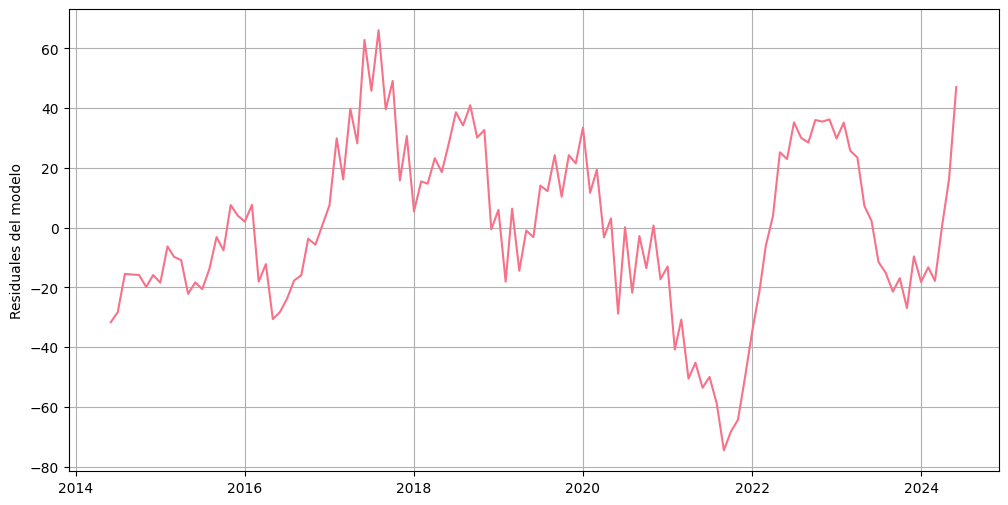

In [67]:
plt.ylabel("Residuales del modelo")
plt.plot(season_pol6_p2.resid)
plt.grid()

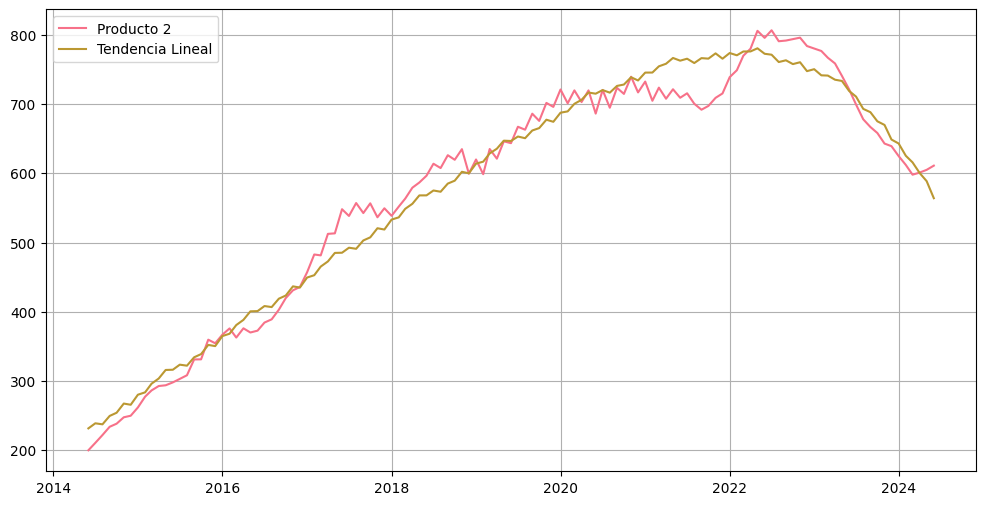

In [68]:
plt.plot(y_p2,label="Producto 2")
plt.plot(season_pol6_p2.fittedvalues,label="Tendencia Lineal")
plt.legend(loc="upper left")
plt.grid()
plt.show()

In [69]:
h=12
x_for_p2= np.linspace((train_estacional_p2.shape[0]+1),(train_estacional_p2.shape[0]+h),h)
x_for_all_p2 = pd.DataFrame(np.stack((x_for_p2, x_for_p2**6),axis=1),columns=["x","x6"] )

range_dates_p2 = pd.date_range(train_estacional_p2.index[-1]+ relativedelta(months=1), periods=h,freq='MS')
x_for_dummies_p2 = pd.get_dummies(range_dates_p2.month,drop_first=True)

X_for_p2= sm.add_constant(pd.concat([x_for_all_p2,x_for_dummies_p2],axis=1))
X_for_p2

,const,x,x6,2,3,4,5,6,7,8,9,10,11,12
0,1.0,122.0,3.297304e+12,False,False,False,False,False,True,False,False,False,False,False
1,1.0,123.0,3.462826e+12,False,False,False,False,False,False,True,False,False,False,False
2,1.0,124.0,3.635215e+12,False,False,False,False,False,False,False,True,False,False,False
3,1.0,125.0,3.814697e+12,False,False,False,False,False,False,False,False,True,False,False
4,1.0,126.0,4.001504e+12,False,False,False,False,False,False,False,False,False,True,False
5,1.0,127.0,4.195873e+12,False,False,False,False,False,False,False,False,False,False,True
6,1.0,128.0,4.398047e+12,False,False,False,False,False,False,False,False,False,False,False
7,1.0,129.0,4.608274e+12,True,False,False,False,False,False,False,False,False,False,False
8,1.0,130.0,4.826809e+12,False,True,False,False,False,False,False,False,False,False,False
9,1.0,131.0,5.053913e+12,False,False,True,False,False,False,False,False,False,False,False


In [70]:
dt_p2 = season_pol6_p2.get_prediction(X_for_p2.astype(int)).summary_frame(alpha = 0.05)
y_prd_p2 = dt_p2['mean']
yprd_ci_lower_p2 = dt_p2['obs_ci_lower']
yprd_ci_upper_p2 = dt_p2['obs_ci_upper']
preds_p2 = pd.DataFrame(np.column_stack([y_prd_p2, yprd_ci_lower_p2, yprd_ci_upper_p2]))
preds_p2.columns = ['Point_forecast', 'lower_95', 'upper_95']
preds_p2.set_index(range_dates_p2,inplace=True)
preds_p2 = preds_p2.iloc[:6]
print(preds_p2)

            Point_forecast    lower_95    upper_95
2024-07-01      545.220058  479.429302  611.010814
2024-08-01      516.614490  450.293672  582.935308
2024-09-01      500.475498  433.565867  567.385129
2024-10-01      475.654544  408.093235  543.215853
2024-11-01      458.290999  390.010937  526.571060
2024-12-01      424.710676  355.640502  493.780849


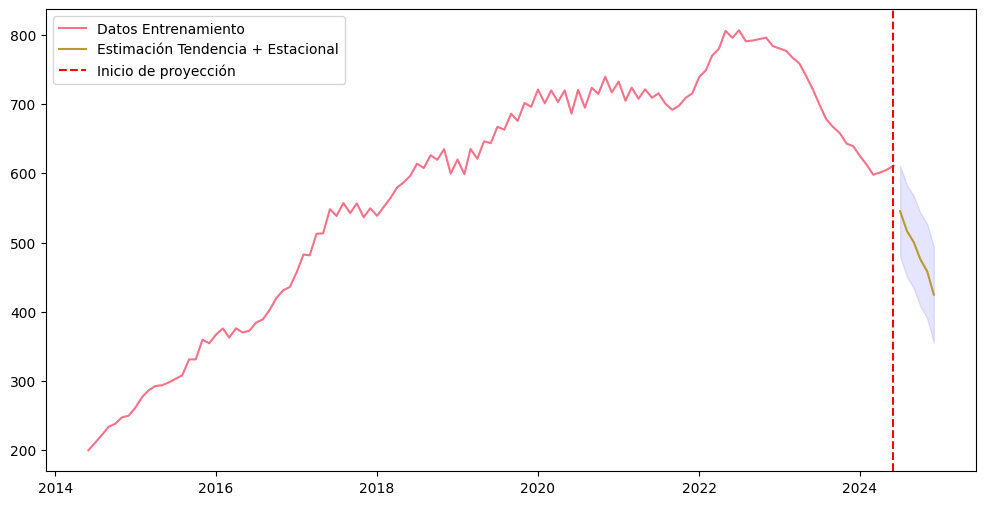

In [71]:
fig = plt.figure(figsize=(12, 6))
plt.plot(y_p2.index,y_p2,label="Datos Entrenamiento")
plt.plot(preds_p2.index,preds_p2['Point_forecast'],label="Estimación Tendencia + Estacional")
plt.axvline(train_estacional_p2.index[-1], color='red', linestyle='--', label='Inicio de proyección')
plt.fill_between(preds_p2.index,preds_p2['lower_95'], preds_p2['upper_95'], color='blue', alpha=0.1)
plt.legend(loc="upper left")
plt.show()

In [72]:
y_true_p2 = train_estacional_p2["producto2"]
y_pred_p2 = season_pol6_p2.fittedvalues

# cálculo del RMSE
rmse_p2 = np.sqrt(mean_squared_error(y_true_p2, y_pred_p2))

print(f"RMSE del modelo tendencia + estacionalidad - Producto 2: {rmse_p2:.2f}")

RMSE del modelo tendencia + estacionalidad - Producto 2: 27.87


## **Validación de supuestos - PRODUCTO 2** ##

In [73]:
# ==================== VALIDACIÓN DE SUPUESTOS DEL MODELO - PRODUCTO 2 ====================
# Modelo: Tendencia Polinómica (grado 6) + Estacionalidad

print("="*70)
print("VALIDACIÓN DE SUPUESTOS - MODELO TENDENCIA + ESTACIONALIDAD - PRODUCTO 2")
print("="*70)

# Extraer residuos del modelo
residuos_p2 = season_pol6_p2.resid

print(f"\n1. ESTADÍSTICAS DESCRIPTIVAS DE RESIDUOS")
print("-"*70)
print(f"   Media de residuos: {residuos_p2.mean():.6f}")
print(f"   Desviación estándar: {residuos_p2.std():.4f}")
print(f"   Mínimo: {residuos_p2.min():.4f}")
print(f"   Máximo: {residuos_p2.max():.4f}")

# ==================== SUPUESTO 1: NORMALIDAD DE RESIDUOS ====================
print(f"\n2. SUPUESTO DE NORMALIDAD")
print("-"*70)

# Test de Jarque-Bera
jb_stat_p2, jb_pvalue_p2 = stats.jarque_bera(residuos_p2)
print(f"   Test Jarque-Bera:")
print(f"      Estadístico: {jb_stat_p2:.4f}")
print(f"      p-value: {jb_pvalue_p2:.4f}")
if jb_pvalue_p2 > 0.05:
    print(f"      ✓ No se rechaza normalidad (p > 0.05)")
else:
    print(f"      ✗ Se rechaza normalidad (p ≤ 0.05)")

# Test de Shapiro-Wilk (más robusto para muestras pequeñas)
sw_stat_p2, sw_pvalue_p2 = stats.shapiro(residuos_p2)
print(f"\n   Test Shapiro-Wilk:")
print(f"      Estadístico: {sw_stat_p2:.4f}")
print(f"      p-value: {sw_pvalue_p2:.4f}")
if sw_pvalue_p2 > 0.05:
    print(f"      ✓ No se rechaza normalidad (p > 0.05)")
else:
    print(f"      ✗ Se rechaza normalidad (p ≤ 0.05)")

# ==================== SUPUESTO 2: HOMOCEDASTICIDAD ====================
print(f"\n3. SUPUESTO DE HOMOCEDASTICIDAD (Varianza Constante)")
print("-"*70)

# Test de Breusch-Pagan
from statsmodels.stats.diagnostic import het_breuschpagan

# Reconstruir X para el test
y_test_p2 = train_estacional_p2["producto2"]
month_dummies_test_p2 = pd.get_dummies(train_estacional_p2.index.month, drop_first=True).set_index(train_estacional_p2.index).astype(int)
X_test_p2 = sm.add_constant(pd.concat([train_estacional_p2[["x", "x6"]], month_dummies_test_p2], axis=1))

bp_stat_p2, bp_pvalue_p2, bp_f_p2, bp_f_pvalue_p2 = het_breuschpagan(residuos_p2, X_test_p2)
print(f"   Test Breusch-Pagan:")
print(f"      Estadístico LM: {bp_stat_p2:.4f}")
print(f"      p-value: {bp_pvalue_p2:.4f}")
if bp_pvalue_p2 > 0.05:
    print(f"      ✓ No se rechaza homocedasticidad (p > 0.05)")
else:
    print(f"      ✗ Se rechaza homocedasticidad - posible heterocedasticidad (p ≤ 0.05)")

# ==================== SUPUESTO 3: INDEPENDENCIA (NO AUTOCORRELACIÓN) ====================
print(f"\n4. SUPUESTO DE INDEPENDENCIA (No Autocorrelación)")
print("-"*70)

# Test de Durbin-Watson
from statsmodels.stats.stattools import durbin_watson
dw_stat_p2 = durbin_watson(residuos_p2)
print(f"   Test Durbin-Watson:")
print(f"      Estadístico DW: {dw_stat_p2:.4f}")
print(f"      Interpretación:")
if 1.5 < dw_stat_p2 < 2.5:
    print(f"      ✓ No hay autocorrelación significativa (1.5 < DW < 2.5)")
elif dw_stat_p2 < 1.5:
    print(f"      ✗ Posible autocorrelación positiva (DW < 1.5)")
else:
    print(f"      ✗ Posible autocorrelación negativa (DW > 2.5)")

# Test de Ljung-Box (autocorrelación en múltiples lags)
ljung_box_result_p2 = acorr_ljungbox(residuos_p2, lags=10, return_df=True)
print(f"\n   Test Ljung-Box (Autocorrelación hasta lag 10):")
print(f"      p-value (lag 10): {ljung_box_result_p2['lb_pvalue'].iloc[-1]:.4f}")
if ljung_box_result_p2['lb_pvalue'].iloc[-1] > 0.05:
    print(f"      ✓ No se detecta autocorrelación significativa (p > 0.05)")
    print(f"      Los residuos parecen ruido blanco")
else:
    print(f"      ✗ Se detecta autocorrelación (p ≤ 0.05)")
    print(f"      Posibles patrones temporales en residuos")

# ==================== SUPUESTO 4: LINEALIDAD ====================
print(f"\n5. SUPUESTO DE LINEALIDAD")
print("-"*70)

# Test RESET de Ramsey
reset_result_p2 = linear_reset(season_pol6_p2, power=2, test_type='fitted', use_f=True)
reset_stat_p2 = reset_result_p2.statistic
reset_pvalue_p2 = reset_result_p2.pvalue

print(f"   Test RESET de Ramsey:")
print(f"      Estadístico F: {reset_stat_p2:.4f}")
print(f"      p-value: {reset_pvalue_p2:.4f}")
if reset_pvalue_p2 > 0.05:
    print(f"      ✓ No se rechaza especificación lineal (p > 0.05)")
    print(f"      El modelo parece bien especificado")
else:
    print(f"      ✗ Posible no linealidad o mala especificación (p ≤ 0.05)")

# ==================== RESUMEN GENERAL ====================
print(f"\n" + "="*70)
print("RESUMEN DE VALIDACIÓN DE SUPUESTOS - PRODUCTO 2")
print("="*70)

supuestos_cumplidos_p2 = []
supuestos_no_cumplidos_p2 = []

if jb_pvalue_p2 > 0.05 and sw_pvalue_p2 > 0.05:
    supuestos_cumplidos_p2.append("✓ Normalidad de residuos")
else:
    supuestos_no_cumplidos_p2.append("✗ Normalidad de residuos")

if bp_pvalue_p2 > 0.05:
    supuestos_cumplidos_p2.append("✓ Homocedasticidad")
else:
    supuestos_no_cumplidos_p2.append("✗ Homocedasticidad")

if 1.5 < dw_stat_p2 < 2.5 and ljung_box_result_p2['lb_pvalue'].iloc[-1] > 0.05:
    supuestos_cumplidos_p2.append("✓ Independencia (No autocorrelación)")
else:
    supuestos_no_cumplidos_p2.append("✗ Independencia (Autocorrelación detectada)")

if reset_pvalue_p2 > 0.05:
    supuestos_cumplidos_p2.append("✓ Especificación lineal correcta")
else:
    supuestos_no_cumplidos_p2.append("✗ Especificación del modelo")

print("\nSupuestos CUMPLIDOS:")
for supuesto in supuestos_cumplidos_p2:
    print(f"   {supuesto}")

if supuestos_no_cumplidos_p2:
    print("\nSupuestos NO CUMPLIDOS:")
    for supuesto in supuestos_no_cumplidos_p2:
        print(f"   {supuesto}")

print("\n" + "="*70)
if len(supuestos_cumplidos_p2) >= 3:
    print("CONCLUSIÓN: El modelo cumple la mayoría de supuestos")
    print("Los resultados son confiables para inferencia y pronóstico")
else:
    print("CONCLUSIÓN: Varios supuestos no se cumplen")
    print("Considerar transformaciones o modelos alternativos")
print("="*70)

VALIDACIÓN DE SUPUESTOS - MODELO TENDENCIA + ESTACIONALIDAD - PRODUCTO 2

1. ESTADÍSTICAS DESCRIPTIVAS DE RESIDUOS
----------------------------------------------------------------------
   Media de residuos: -0.000050
   Desviación estándar: 27.9897
   Mínimo: -74.4710
   Máximo: 66.0671

2. SUPUESTO DE NORMALIDAD
----------------------------------------------------------------------
   Test Jarque-Bera:
      Estadístico: 0.8113
      p-value: 0.6665
      ✓ No se rechaza normalidad (p > 0.05)

   Test Shapiro-Wilk:
      Estadístico: 0.9863
      p-value: 0.2609
      ✓ No se rechaza normalidad (p > 0.05)

3. SUPUESTO DE HOMOCEDASTICIDAD (Varianza Constante)
----------------------------------------------------------------------
   Test Breusch-Pagan:
      Estadístico LM: 20.2816
      p-value: 0.0884
      ✓ No se rechaza homocedasticidad (p > 0.05)

4. SUPUESTO DE INDEPENDENCIA (No Autocorrelación)
----------------------------------------------------------------------
   Test Durbi

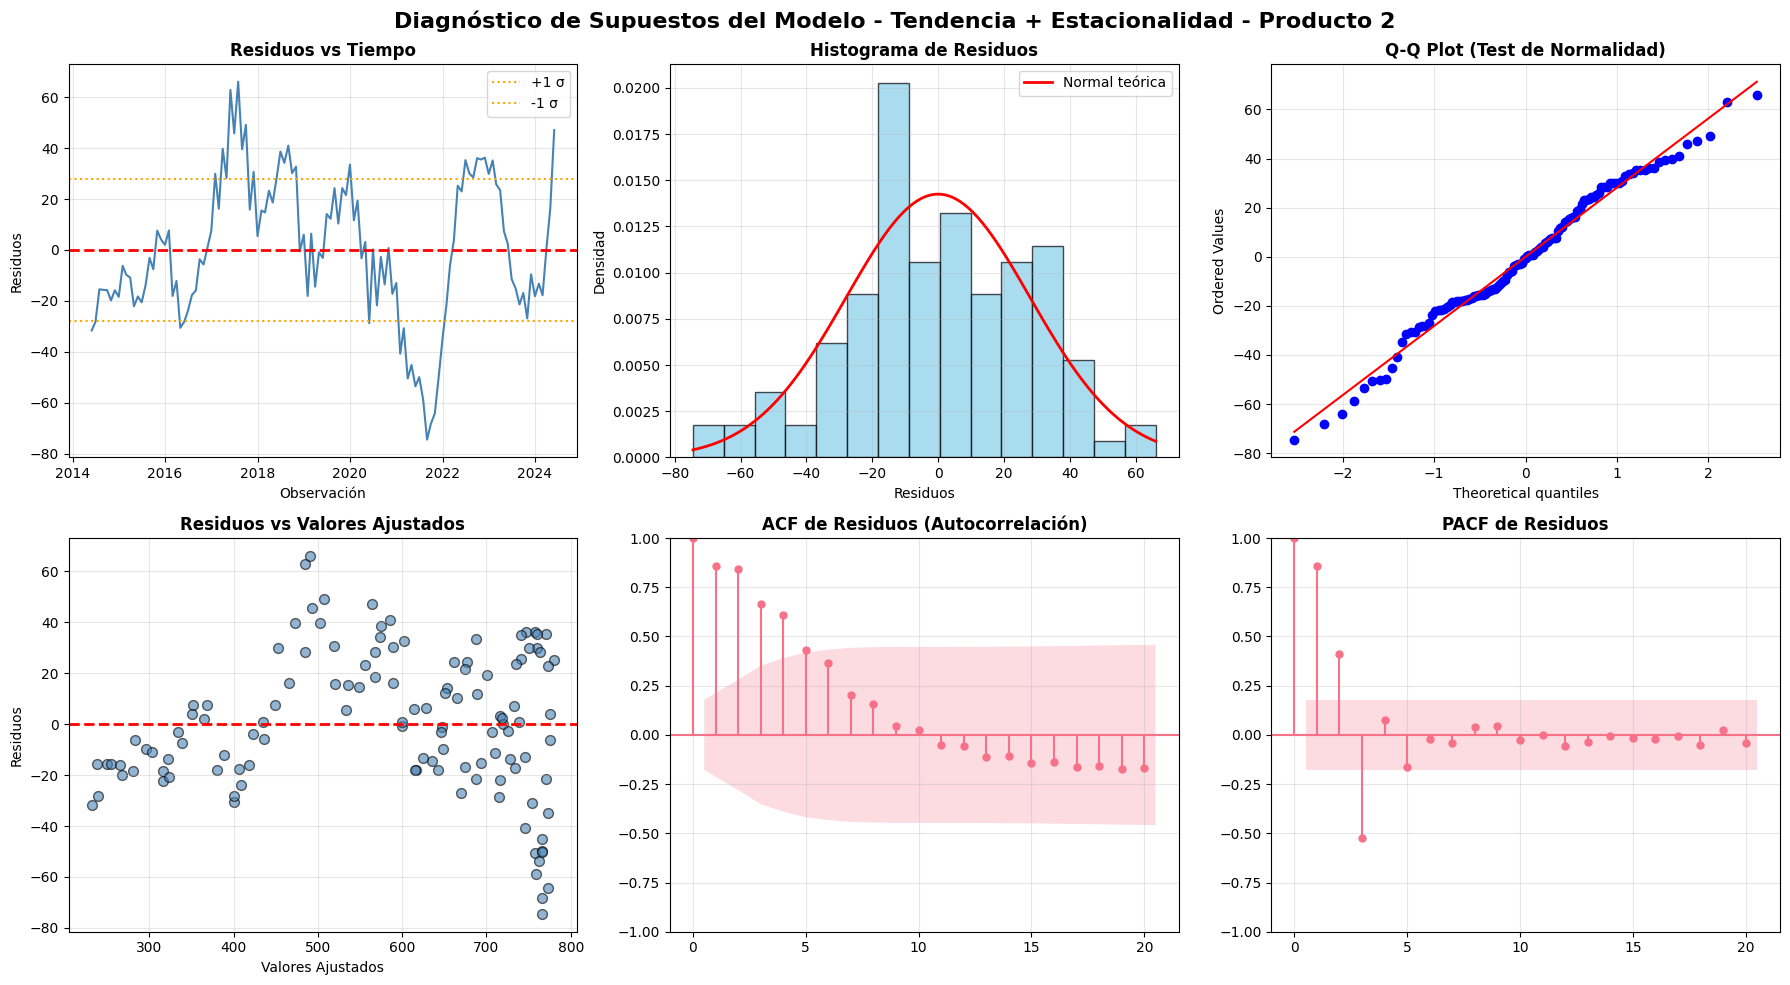

In [74]:
# ==================== VISUALIZACIÓN DE SUPUESTOS - PRODUCTO 2 ====================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Diagnóstico de Supuestos del Modelo - Tendencia + Estacionalidad - Producto 2', 
             fontsize=16, fontweight='bold')

# 1. Residuos vs Tiempo
axes[0, 0].plot(residuos_p2, color='steelblue', linewidth=1.5)
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0, 0].axhline(y=residuos_p2.std(), color='orange', linestyle=':', linewidth=1.5, label='+1 σ')
axes[0, 0].axhline(y=-residuos_p2.std(), color='orange', linestyle=':', linewidth=1.5, label='-1 σ')
axes[0, 0].set_title('Residuos vs Tiempo', fontweight='bold')
axes[0, 0].set_xlabel('Observación')
axes[0, 0].set_ylabel('Residuos')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. Histograma de Residuos
axes[0, 1].hist(residuos_p2, bins=15, color='skyblue', edgecolor='black', alpha=0.7, density=True)
# Superponer distribución normal
mu, sigma = residuos_p2.mean(), residuos_p2.std()
x = np.linspace(residuos_p2.min(), residuos_p2.max(), 100)
axes[0, 1].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normal teórica')
axes[0, 1].set_title('Histograma de Residuos', fontweight='bold')
axes[0, 1].set_xlabel('Residuos')
axes[0, 1].set_ylabel('Densidad')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 3. Q-Q Plot (Normalidad)
stats.probplot(residuos_p2, dist="norm", plot=axes[0, 2])
axes[0, 2].set_title('Q-Q Plot (Test de Normalidad)', fontweight='bold')
axes[0, 2].grid(alpha=0.3)

# 4. Residuos vs Valores Ajustados (Homocedasticidad)
fitted_values_p2 = season_pol6_p2.fittedvalues
axes[1, 0].scatter(fitted_values_p2, residuos_p2, alpha=0.6, color='steelblue', edgecolors='black', s=50)
axes[1, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 0].set_title('Residuos vs Valores Ajustados', fontweight='bold')
axes[1, 0].set_xlabel('Valores Ajustados')
axes[1, 0].set_ylabel('Residuos')
axes[1, 0].grid(alpha=0.3)

# 5. ACF de Residuos (Autocorrelación)
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuos_p2, lags=20, ax=axes[1, 1], alpha=0.05)
axes[1, 1].set_title('ACF de Residuos (Autocorrelación)', fontweight='bold')
axes[1, 1].grid(alpha=0.3)

# 6. PACF de Residuos
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(residuos_p2, lags=20, ax=axes[1, 2], alpha=0.05)
axes[1, 2].set_title('PACF de Residuos', fontweight='bold')
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# COMPARACIÓN DE MODELOS Y RESULTADOS

## Consolidación de métricas de rendimiento

In [75]:
# Consolidar todas las métricas de los modelos
# Producto 1
rmse_lineal_p1 = rmse
rmse_cuadratico_p1 = rmse_quad
rmse_polinomico_p1 = tabla_resultados.loc[mejor_grado, 'RMSE (test)']
rmse_estacional_p1 = np.sqrt(mean_squared_error(train_estacional["producto1"], season.fittedvalues))
rmse_tendencia_estacional_p1 = np.sqrt(mean_squared_error(train_estacional["producto1"], season_pol6.fittedvalues))

# Producto 2
# Necesitamos calcular RMSE lineal para producto 2 con los datos de test
rmse_lineal_p2 = np.sqrt(mean_squared_error(test_to2["producto2"], lin_t_p2.predict(sm.add_constant(test_to2[['x']]))))
rmse_cuadratico_p2 = rmse_quad_p2
rmse_polinomico_p2 = tabla_resultados_p2.loc[mejor_grado_p2, 'RMSE (test)']
rmse_estacional_p2 = np.sqrt(mean_squared_error(train_estacional_p2["producto2"], season_p2.fittedvalues))
rmse_tendencia_estacional_p2 = np.sqrt(mean_squared_error(train_estacional_p2["producto2"], season_pol6_p2.fittedvalues))

# Crear DataFrame comparativo
comparacion_modelos = pd.DataFrame({
    'Producto 1': [
        rmse_lineal_p1,
        rmse_cuadratico_p1,
        rmse_polinomico_p1,
        rmse_estacional_p1,
        rmse_tendencia_estacional_p1
    ],
    'Producto 2': [
        rmse_lineal_p2,
        rmse_cuadratico_p2,
        rmse_polinomico_p2,
        rmse_estacional_p2,
        rmse_tendencia_estacional_p2
    ]
}, index=[
    'Tendencia Lineal',
    'Tendencia Cuadrática',
    f'Tendencia Polinómica (grado {mejor_grado})',
    'Estacionalidad',
    'Tendencia + Estacionalidad'
])

print("="*70)
print("COMPARACIÓN DE RMSE POR MODELO Y PRODUCTO")
print("="*70)
print(comparacion_modelos.round(2))
print("\nMejor modelo por producto:")
print(f"  Producto 1: {comparacion_modelos['Producto 1'].idxmin()} (RMSE = {comparacion_modelos['Producto 1'].min():.2f})")
print(f"  Producto 2: {comparacion_modelos['Producto 2'].idxmin()} (RMSE = {comparacion_modelos['Producto 2'].min():.2f})")

COMPARACIÓN DE RMSE POR MODELO Y PRODUCTO
                                Producto 1  Producto 2
Tendencia Lineal                     47.98      199.42
Tendencia Cuadrática                 88.16       28.08
Tendencia Polinómica (grado 7)       62.83       28.08
Estacionalidad                       91.92      169.73
Tendencia + Estacionalidad           47.98       27.87

Mejor modelo por producto:
  Producto 1: Tendencia Lineal (RMSE = 47.98)
  Producto 2: Tendencia + Estacionalidad (RMSE = 27.87)


## Visualización comparativa de modelos

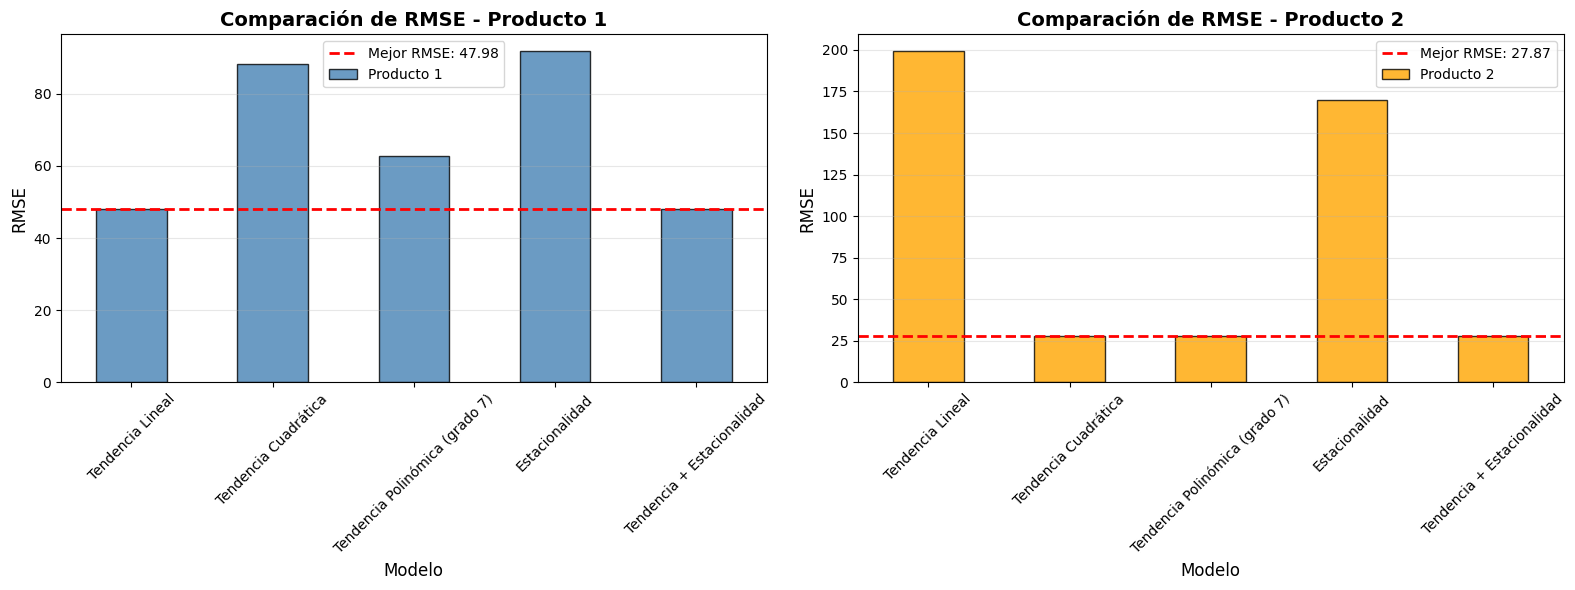

In [76]:
# Gráfico de barras comparativo de RMSE
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Producto 1
ax1 = axes[0]
comparacion_modelos['Producto 1'].plot(kind='bar', ax=ax1, color='steelblue', edgecolor='black', alpha=0.8)
ax1.set_title('Comparación de RMSE - Producto 1', fontsize=14, fontweight='bold')
ax1.set_ylabel('RMSE', fontsize=12)
ax1.set_xlabel('Modelo', fontsize=12)
ax1.axhline(y=comparacion_modelos['Producto 1'].min(), color='red', linestyle='--', 
            linewidth=2, label=f'Mejor RMSE: {comparacion_modelos["Producto 1"].min():.2f}')
ax1.legend()
ax1.grid(alpha=0.3, axis='y')
ax1.tick_params(axis='x', rotation=45)

# Producto 2
ax2 = axes[1]
comparacion_modelos['Producto 2'].plot(kind='bar', ax=ax2, color='orange', edgecolor='black', alpha=0.8)
ax2.set_title('Comparación de RMSE - Producto 2', fontsize=14, fontweight='bold')
ax2.set_ylabel('RMSE', fontsize=12)
ax2.set_xlabel('Modelo', fontsize=12)
ax2.axhline(y=comparacion_modelos['Producto 2'].min(), color='red', linestyle='--', 
            linewidth=2, label=f'Mejor RMSE: {comparacion_modelos["Producto 2"].min():.2f}')
ax2.legend()
ax2.grid(alpha=0.3, axis='y')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

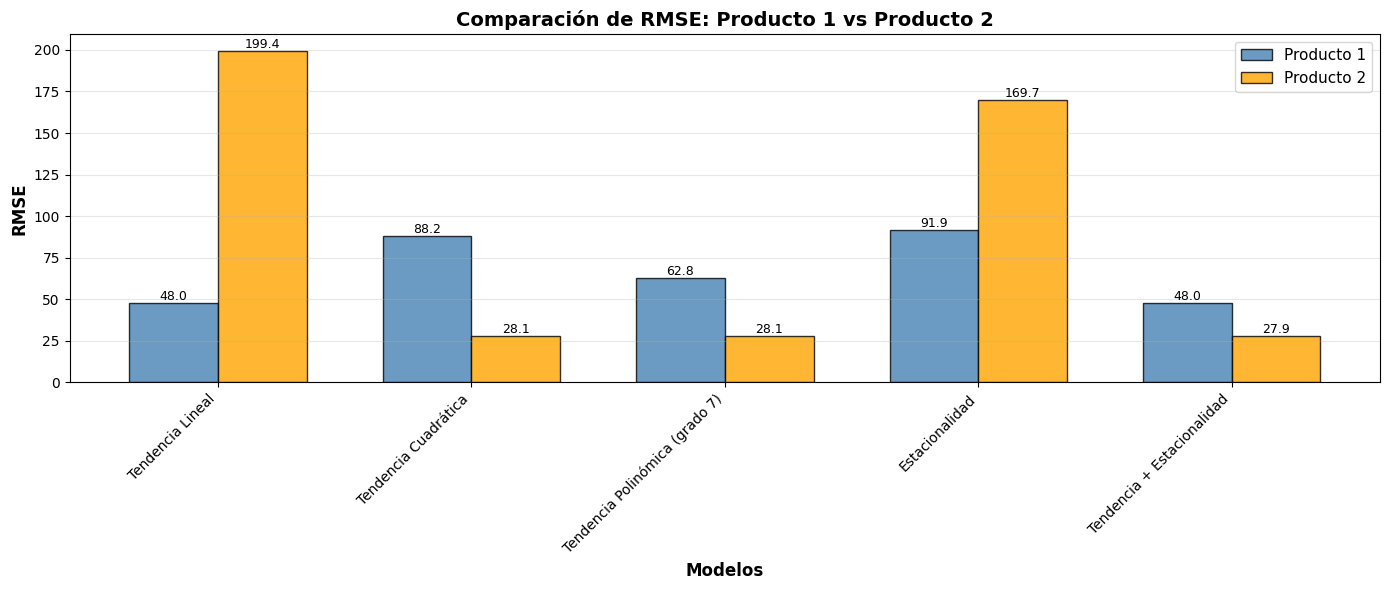

In [77]:
# Comparación lado a lado
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(comparacion_modelos.index))
width = 0.35

bars1 = ax.bar(x - width/2, comparacion_modelos['Producto 1'], width, 
               label='Producto 1', color='steelblue', edgecolor='black', alpha=0.8)
bars2 = ax.bar(x + width/2, comparacion_modelos['Producto 2'], width, 
               label='Producto 2', color='orange', edgecolor='black', alpha=0.8)

ax.set_xlabel('Modelos', fontsize=12, fontweight='bold')
ax.set_ylabel('RMSE', fontsize=12, fontweight='bold')
ax.set_title('Comparación de RMSE: Producto 1 vs Producto 2', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparacion_modelos.index, rotation=45, ha='right')
ax.legend(fontsize=11)
ax.grid(alpha=0.3, axis='y')

# Añadir valores sobre las barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## Resumen de validación de supuestos

In [78]:
# Resumen de supuestos cumplidos
validacion_supuestos = pd.DataFrame({
    'Producto 1': {
        'Normalidad': 'Cumple' if jb_pvalue > 0.05 and sw_pvalue > 0.05 else 'No cumple',
        'Homocedasticidad': 'Cumple' if bp_pvalue > 0.05 else 'No cumple',
        'Independencia': 'Cumple' if 1.5 < dw_stat < 2.5 and ljung_box_result['lb_pvalue'].iloc[-1] > 0.05 else 'No cumple',
        'Linealidad': 'Cumple' if reset_pvalue > 0.05 else 'No cumple'
    },
    'Producto 2': {
        'Normalidad': 'Cumple' if jb_pvalue_p2 > 0.05 and sw_pvalue_p2 > 0.05 else 'No cumple',
        'Homocedasticidad': 'Cumple' if bp_pvalue_p2 > 0.05 else 'No cumple',
        'Independencia': 'Cumple' if 1.5 < dw_stat_p2 < 2.5 and ljung_box_result_p2['lb_pvalue'].iloc[-1] > 0.05 else 'No cumple',
        'Linealidad': 'Cumple' if reset_pvalue_p2 > 0.05 else 'No cumple'
    }
}).T

print("="*70)
print("RESUMEN DE VALIDACIÓN DE SUPUESTOS (Modelo Tendencia + Estacionalidad)")
print("="*70)
print(validacion_supuestos)
print("\n")

# Contar supuestos cumplidos
for producto in ['Producto 1', 'Producto 2']:
    cumple = (validacion_supuestos.loc[producto] == 'Cumple').sum()
    total = len(validacion_supuestos.columns)
    print(f"{producto}: {cumple}/{total} supuestos cumplidos ({100*cumple/total:.1f}%)")

RESUMEN DE VALIDACIÓN DE SUPUESTOS (Modelo Tendencia + Estacionalidad)
           Normalidad Homocedasticidad Independencia Linealidad
Producto 1     Cumple        No cumple     No cumple  No cumple
Producto 2     Cumple           Cumple     No cumple  No cumple


Producto 1: 1/4 supuestos cumplidos (25.0%)
Producto 2: 2/4 supuestos cumplidos (50.0%)


## Guardado de resultados en pickle

In [79]:
# Consolidar todos los resultados en un diccionario
resultados_tendencias = {
    # Métricas de rendimiento
    'comparacion_rmse': comparacion_modelos,
    
    # Mejor modelo por producto
    'mejor_modelo_p1': comparacion_modelos['Producto 1'].idxmin(),
    'mejor_rmse_p1': comparacion_modelos['Producto 1'].min(),
    'mejor_modelo_p2': comparacion_modelos['Producto 2'].idxmin(),
    'mejor_rmse_p2': comparacion_modelos['Producto 2'].min(),
    
    # Validación de supuestos
    'validacion_supuestos': validacion_supuestos,
    'supuestos_cumplidos_p1': supuestos_cumplidos,
    'supuestos_no_cumplidos_p1': supuestos_no_cumplidos,
    'supuestos_cumplidos_p2': supuestos_cumplidos_p2,
    'supuestos_no_cumplidos_p2': supuestos_no_cumplidos_p2,
    
    # Modelos ajustados - Producto 1
    'modelo_lineal_p1': lin_t,
    'modelo_cuadratico_p1': pol_2,
    'modelo_polinomico_p1': modelo_final,
    'modelo_estacional_p1': season,
    'modelo_tendencia_estacional_p1': season_pol6,
    
    # Modelos ajustados - Producto 2
    'modelo_lineal_p2': lin_t_p2,
    'modelo_cuadratico_p2': pol_2_p2,
    'modelo_polinomico_p2': modelo_final_p2,
    'modelo_estacional_p2': season_p2,
    'modelo_tendencia_estacional_p2': season_pol6_p2,
    
    # Información adicional
    'mejor_grado_polinomico_p1': mejor_grado,
    'mejor_grado_polinomico_p2': mejor_grado_p2,
    'tabla_grados_p1': tabla_resultados,
    'tabla_grados_p2': tabla_resultados_p2,
    
    # Datos para pronósticos
    'train_estacional_p1': train_estacional,
    'train_estacional_p2': train_estacional_p2,
    'test_to1': test_to1,
    'test_to2': test_to2
}

# Guardar en pickle
with open('resultados_tendencias.pkl', 'wb') as f:
    pickle.dump(resultados_tendencias, f)

print("="*70)
print("RESULTADOS GUARDADOS EXITOSAMENTE")
print("="*70)
print(f"Archivo: resultados_tendencias.pkl")
print(f"\nContenido guardado:")
print(f"  - Comparación de RMSE para ambos productos")
print(f"  - Mejores modelos identificados:")
print(f"      * Producto 1: {resultados_tendencias['mejor_modelo_p1']} (RMSE={resultados_tendencias['mejor_rmse_p1']:.2f})")
print(f"      * Producto 2: {resultados_tendencias['mejor_modelo_p2']} (RMSE={resultados_tendencias['mejor_rmse_p2']:.2f})")
print(f"  - Validación de supuestos para ambos productos")
print(f"  - 5 modelos ajustados por producto (10 modelos totales)")
print(f"  - Datos de entrenamiento y test")
print(f"  - Tablas de evaluación de grados polinómicos")
print("="*70)

RESULTADOS GUARDADOS EXITOSAMENTE
Archivo: resultados_tendencias.pkl

Contenido guardado:
  - Comparación de RMSE para ambos productos
  - Mejores modelos identificados:
      * Producto 1: Tendencia Lineal (RMSE=47.98)
      * Producto 2: Tendencia + Estacionalidad (RMSE=27.87)
  - Validación de supuestos para ambos productos
  - 5 modelos ajustados por producto (10 modelos totales)
  - Datos de entrenamiento y test
  - Tablas de evaluación de grados polinómicos


## Verificación de guardado

In [80]:
# Verificar que el archivo se guardó correctamente
import os

if os.path.exists('resultados_tendencias.pkl'):
    file_size = os.path.getsize('resultados_tendencias.pkl')
    print(f"✓ Archivo 'resultados_tendencias.pkl' guardado exitosamente")
    print(f"  Tamaño: {file_size:,} bytes ({file_size/1024:.2f} KB)")
    
    # Cargar y verificar contenido
    with open('resultados_tendencias.pkl', 'rb') as f:
        verificacion = pickle.load(f)
    
    print(f"\n✓ Verificación de contenido:")
    print(f"  Total de elementos: {len(verificacion)}")
    print(f"\n  Claves principales:")
    for key in verificacion.keys():
        print(f"    - {key}")
else:
    print("✗ Error: El archivo no se guardó correctamente")

✓ Archivo 'resultados_tendencias.pkl' guardado exitosamente
  Tamaño: 277,644 bytes (271.14 KB)

✓ Verificación de contenido:
  Total de elementos: 28

  Claves principales:
    - comparacion_rmse
    - mejor_modelo_p1
    - mejor_rmse_p1
    - mejor_modelo_p2
    - mejor_rmse_p2
    - validacion_supuestos
    - supuestos_cumplidos_p1
    - supuestos_no_cumplidos_p1
    - supuestos_cumplidos_p2
    - supuestos_no_cumplidos_p2
    - modelo_lineal_p1
    - modelo_cuadratico_p1
    - modelo_polinomico_p1
    - modelo_estacional_p1
    - modelo_tendencia_estacional_p1
    - modelo_lineal_p2
    - modelo_cuadratico_p2
    - modelo_polinomico_p2
    - modelo_estacional_p2
    - modelo_tendencia_estacional_p2
    - mejor_grado_polinomico_p1
    - mejor_grado_polinomico_p2
    - tabla_grados_p1
    - tabla_grados_p2
    - train_estacional_p1
    - train_estacional_p2
    - test_to1
    - test_to2
